# Notebook 05 — Эксперимент 3: Секторальная независимость

## Исследовательский вопрос
**«Насколько акция самостоятельна внутри своего сектора —
или она просто ходит вместе со всеми?»**

## Практическая ценность
Инвестор выбирает акции внутри сектора.
Какие дадут реальную диверсификацию,
а какие дублируют сектор целиком?

## Метрики (3 показателя)
| Метрика | Что измеряет |
|---|---|
| corr_sector | Корреляция акции с ETF своего сектора |
| beta_sector | Бета акции относительно сектора |
| corr_residual | Корреляция идиосинкратической компоненты с рынком |

## Отличие от Эксперимента 4
Эксп.4 измеряет связь с рынком (S&P 500).
Эксп.3 измеряет связь с **собственным сектором**.
Это разные вопросы: акция может быть независимой от рынка
но полностью зависимой от своего сектора — и наоборот.

## 1. Импорты и загрузка

In [20]:
import warnings, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from scipy.optimize import linear_sum_assignment
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import RobustScaler, MinMaxScaler
from sklearn.metrics import (
    silhouette_score, silhouette_samples,
    calinski_harabasz_score, davies_bouldin_score,
    adjusted_rand_score
)
from scipy.cluster.hierarchy import dendrogram, linkage

warnings.filterwarnings('ignore')
plt.rcParams.update({
    'figure.dpi': 150, 'axes.spines.top': False,
    'axes.spines.right': False, 'figure.facecolor': 'white',
    'font.size': 10,
})

# ── Данные ───────────────────────────────────────────────────
simple_returns = pd.read_parquet('data/simple_returns.parquet')
sp500_ret      = pd.read_parquet('data/sp500_index.parquet')['sp500']
meta           = pd.read_csv('data/sp500_meta.csv',
                             index_col='ticker')
res_exp1       = pd.read_parquet('data/results_exp1.parquet')
res_exp2       = pd.read_parquet('data/results_exp2.parquet')

with open('data/feature_groups.json') as f:
    FEATURE_GROUPS = json.load(f)

FEATURES    = ['corr_sector', 'beta_sector', 'corr_residual']
LABELS      = {
    'corr_sector'  : 'Корр. с сектором',
    'beta_sector'  : 'Бета к сектору',
    'corr_residual': 'Корр. остатков',
}
EXP_NAME    = 'Эксперимент 3: Секторальная независимость'
SAVE_PREFIX = 'plots/05_exp3'
RISK_FREE   = 0.04 / 252

SECTOR_ETFS = {
    'Information Technology': 'XLK',
    'Health Care'           : 'XLV',
    'Financials'            : 'XLF',
    'Consumer Discretionary': 'XLY',
    'Industrials'           : 'XLI',
    'Consumer Staples'      : 'XLP',
    'Energy'                : 'XLE',
    'Real Estate'           : 'XLRE',
    'Materials'             : 'XLB',
    'Utilities'             : 'XLU',
    'Communication Services': 'XLC',
}

print("Загружаем секторальные ETF 2019–2024...")
etf_prices  = yf.download(
    list(SECTOR_ETFS.values()),
    start='2019-01-01', end='2024-12-31',
    auto_adjust=True, progress=False
)['Close']
etf_returns = etf_prices.pct_change().dropna()
print(f"ETF: {etf_returns.shape}, "
      f"{etf_returns.index[0].date()} → "
      f"{etf_returns.index[-1].date()}")

Загружаем секторальные ETF 2019–2024...
ETF: (1508, 11), 2019-01-03 → 2024-12-30


## 2. Расчёт метрик секторальной независимости

In [21]:
# Инвертируем словарь ETF → сектор
ETF_TO_SECTOR = {v: k for k, v in SECTOR_ETFS.items()}

def compute_sector_features(stock_ret, sector_ret,
                             market_ret):
    """
    corr_sector:   корреляция акции с ETF сектора
    beta_sector:   бета акции относительно сектора
    corr_residual: корреляция идиосинкратической компоненты
                   (остатков регрессии на рынок) с рынком
                   → низкое значение = акция независима от рынка
                     даже после вычета секторального влияния
    """
    # Выравниваем индексы
    common = stock_ret.index\
             .intersection(sector_ret.index)\
             .intersection(market_ret.index)
    s  = stock_ret.loc[common].dropna()
    sc = sector_ret.loc[common].reindex(s.index).dropna()
    m  = market_ret.loc[common].reindex(s.index).dropna()
    s  = s.reindex(sc.index)

    if len(s) < 200:
        return [np.nan] * 3

    # corr_sector
    corr_s = float(s.corr(sc))

    # beta_sector
    cov_mat  = np.cov(s.values, sc.values)
    beta_s   = float(cov_mat[0,1] / cov_mat[1,1]) \
               if cov_mat[1,1] > 1e-10 else np.nan

    # corr_residual:
    # вычитаем рыночную компоненту из акции и из сектора
    # остатки = идиосинкратическая часть
    cov_sm = np.cov(s.values, m.values)
    beta_m = float(cov_sm[0,1] / cov_sm[1,1]) \
             if cov_sm[1,1] > 1e-10 else np.nan
    resid_stock  = s  - beta_m * m

    cov_scm = np.cov(sc.values, m.values)
    beta_sc_m = float(cov_scm[0,1] / cov_scm[1,1]) \
                if cov_scm[1,1] > 1e-10 else np.nan
    resid_sector = sc - beta_sc_m * m

    corr_r = float(resid_stock.corr(resid_sector))

    return [corr_s, beta_s, corr_r]


print("Рассчитываем метрики секторальной независимости...")
recs = []
skipped_no_sector = 0

for ticker in simple_returns.columns:
    if ticker not in meta.index:
        skipped_no_sector += 1
        continue
    sector = meta.loc[ticker, 'sector']
    etf    = SECTOR_ETFS.get(sector)
    if etf is None or etf not in etf_returns.columns:
        skipped_no_sector += 1
        continue
    try:
        sr  = simple_returns[ticker].dropna()
        sec = etf_returns[etf].dropna()
        mkt = sp500_ret.dropna()
        feats = compute_sector_features(sr, sec, mkt)
        if not any(np.isnan(f) for f in feats):
            recs.append({
                'ticker': ticker,
                'sector': sector,
                **dict(zip(FEATURES, feats))
            })
    except Exception:
        pass

X_raw = pd.DataFrame(recs).set_index('ticker')
X_raw = X_raw.join(meta['name'], how='left')

print(f"Акций с метриками: {len(X_raw)}")
print(f"Пропущено (нет сектора/ETF): {skipped_no_sector}")
print()
print("Описательная статистика:")
print(X_raw[FEATURES].describe().round(3).to_string())

Рассчитываем метрики секторальной независимости...
Акций с метриками: 481
Пропущено (нет сектора/ETF): 0

Описательная статистика:
       corr_sector  beta_sector  corr_residual
count      481.000      481.000        481.000
mean         0.676        0.994          0.390
std          0.131        0.238          0.246
min          0.204        0.331         -0.221
25%          0.586        0.843          0.204
50%          0.673        0.986          0.376
75%          0.779        1.124          0.573
max          0.935        2.268          0.911


## 3. Распределения метрик

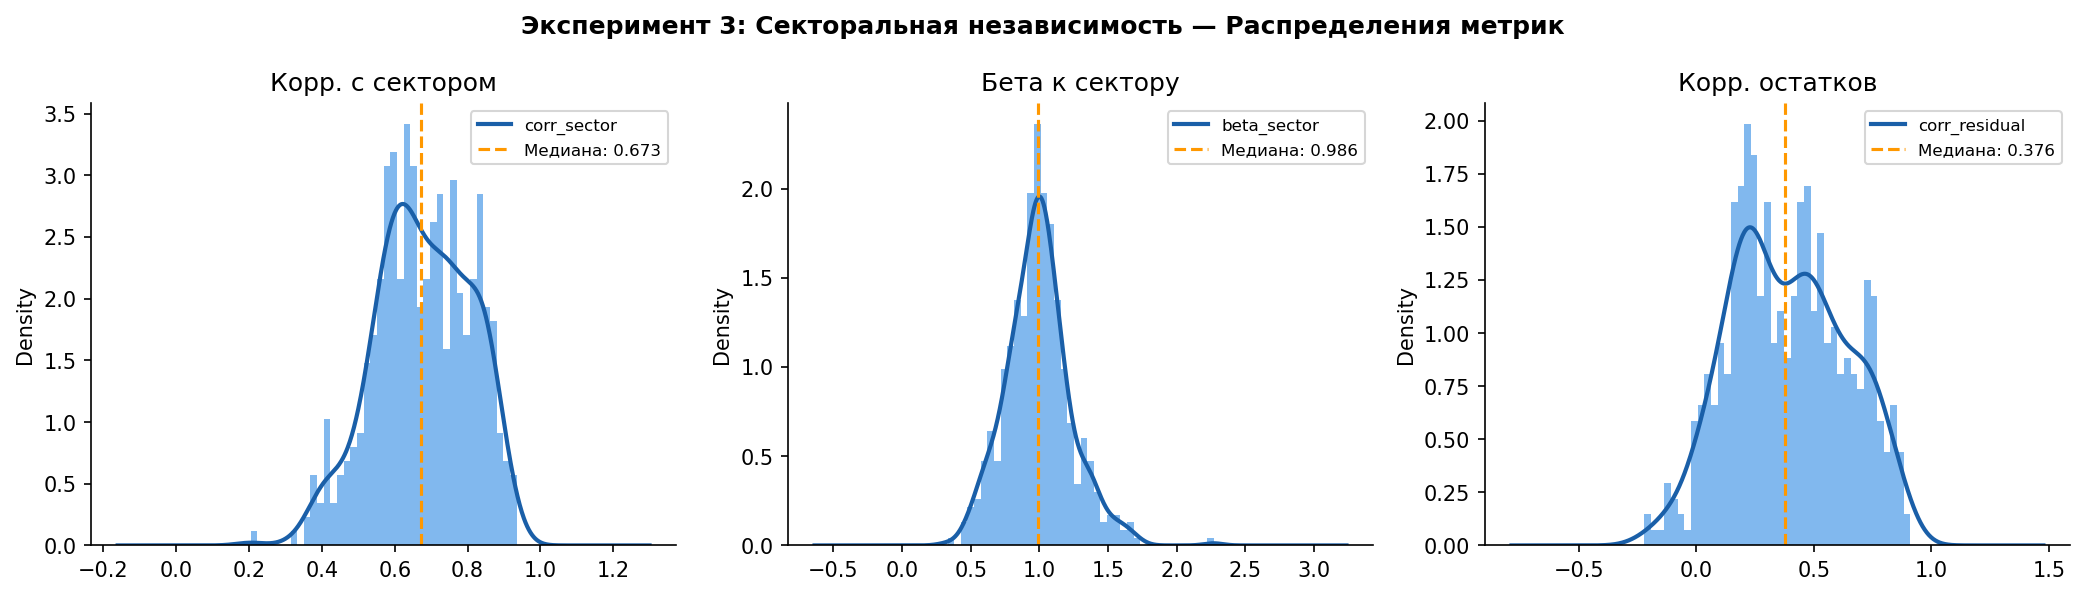

Ключевые наблюдения:
  Корр. с сектором      : медиана=0.673, IQR=[0.586, 0.779]
  Бета к сектору        : медиана=0.986, IQR=[0.843, 1.124]
  Корр. остатков        : медиана=0.376, IQR=[0.204, 0.573]

Средняя corr_sector по секторам:
  Communication Services        : 0.549
  Health Care                   : 0.591
  Consumer Discretionary        : 0.594
  Consumer Staples              : 0.601
  Information Technology        : 0.663
  Materials                     : 0.693
  Industrials                   : 0.700
  Financials                    : 0.730
  Real Estate                   : 0.754
  Utilities                     : 0.802
  Energy                        : 0.802


In [22]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle(f'{EXP_NAME} — Распределения метрик',
             fontsize=12, fontweight='bold')

for ax, feat in zip(axes, FEATURES):
    data = X_raw[feat].dropna()
    ax.hist(data, bins=40, color='#4C9BE8',
            alpha=0.7, density=True)
    data.plot.kde(ax=ax, color='#1a5fa8', linewidth=2)
    ax.axvline(data.median(), color='#FF9800',
               linestyle='--', linewidth=1.5,
               label=f'Медиана: {data.median():.3f}')
    ax.set_title(LABELS[feat])
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(f'{SAVE_PREFIX}_distributions.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("Ключевые наблюдения:")
for feat in FEATURES:
    d = X_raw[feat]
    print(f"  {LABELS[feat]:22s}: "
          f"медиана={d.median():.3f}, "
          f"IQR=[{d.quantile(0.25):.3f}, "
          f"{d.quantile(0.75):.3f}]")

# Корреляция по секторам
print("\nСредняя corr_sector по секторам:")
sector_corr = X_raw.groupby('sector')['corr_sector'].mean()
for sec, val in sector_corr.sort_values().items():
    print(f"  {sec:30s}: {val:.3f}")

## 4. Масштабирование и выбор K

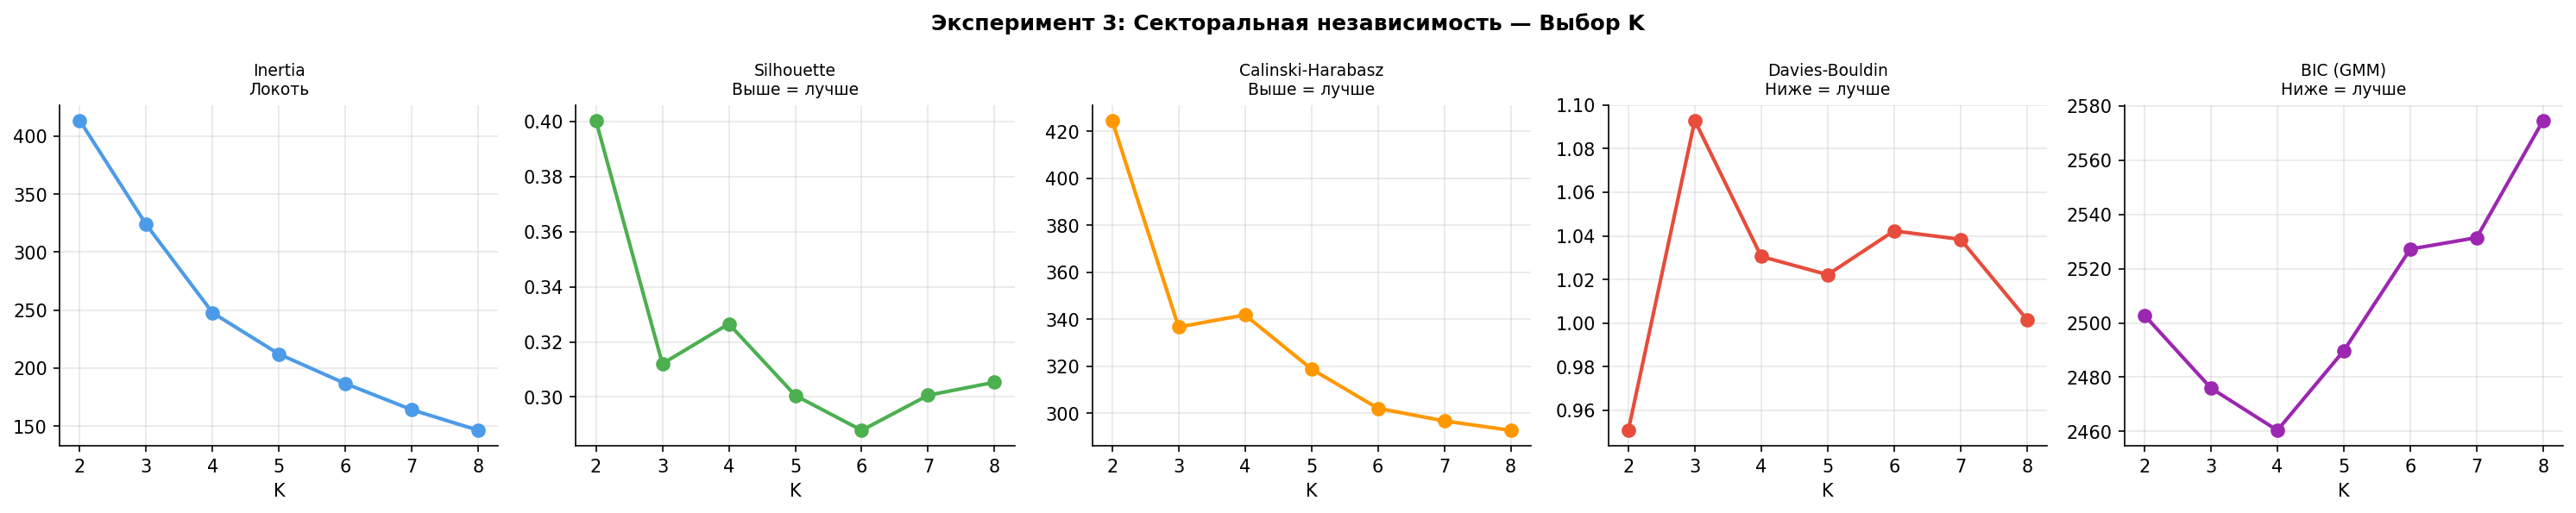

   Inertia  Silhouette     CH     DB  BIC(GMM)
K                                             
2    413.4       0.400  424.6  0.951    2502.8
3    323.7       0.312  336.7  1.093    2476.0
4    247.5       0.327  341.9  1.031    2460.4
5    211.9       0.301  318.9  1.022    2489.8
6    186.5       0.288  302.1  1.042    2527.2
7    163.9       0.301  296.8  1.038    2531.4
8    146.2       0.305  292.8  1.002    2574.6


In [23]:
scaler   = RobustScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X_raw[FEATURES]),
    index=X_raw.index, columns=FEATURES
)

K_RANGE = range(2, 9)
inertias, silhouettes, ch_scores, \
    db_scores, bic_scores = [], [], [], [], []

for k in K_RANGE:
    km  = KMeans(n_clusters=k, random_state=42, n_init=20)
    lbl = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, lbl))
    ch_scores.append(calinski_harabasz_score(X_scaled, lbl))
    db_scores.append(davies_bouldin_score(X_scaled, lbl))
    g = GaussianMixture(n_components=k,
                        random_state=42, n_init=5)
    g.fit(X_scaled)
    bic_scores.append(g.bic(X_scaled))

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
fig.suptitle(f'{EXP_NAME} — Выбор K',
             fontsize=12, fontweight='bold')
for ax, (vals, title, sub, color) in zip(axes, [
    (inertias,    'Inertia',           'Локоть',       '#4C9BE8'),
    (silhouettes, 'Silhouette',        'Выше = лучше', '#4CAF50'),
    (ch_scores,   'Calinski-Harabasz', 'Выше = лучше', '#FF9800'),
    (db_scores,   'Davies-Bouldin',    'Ниже = лучше', '#e74c3c'),
    (bic_scores,  'BIC (GMM)',         'Ниже = лучше', '#9C27B0'),
]):
    ax.plot(list(K_RANGE), vals, 'o-',
            color=color, linewidth=2, markersize=7)
    ax.set_title(f'{title}\n{sub}', fontsize=9)
    ax.set_xlabel('K')
    ax.set_xticks(list(K_RANGE))
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{SAVE_PREFIX}_k_selection.png',
            dpi=150, bbox_inches='tight')
plt.show()

k_table = pd.DataFrame({
    'K'         : list(K_RANGE),
    'Inertia'   : [round(v,1) for v in inertias],
    'Silhouette': [round(v,3) for v in silhouettes],
    'CH'        : [round(v,1) for v in ch_scores],
    'DB'        : [round(v,3) for v in db_scores],
    'BIC(GMM)'  : [round(v,1) for v in bic_scores],
}).set_index('K')
print(k_table.to_string())

Эксперимент 3: Секторальная независимость — Агломеративная кластеризация (Ward)

Доступные признаки для вывода профилей: ['corr_sector ', 'beta_sector', 'corr_residual']

Расстояния последних слияний (дендрограмма):
  K=8→7: dist=4.908, gap=1.438
  K=7→6: dist=6.346, gap=0.456
  K=6→5: dist=6.802, gap=0.479
  K=5→4: dist=7.281, gap=1.812
  K=4→3: dist=9.092, gap=3.293
  K=3→2: dist=12.386, gap=3.639
  K=2→1: dist=16.024, gap=8.483 ← МАКСИМУМ

→ Дендрограмма предлагает K=2

Метрики качества для K=2..8 (агломеративная кластеризация)

   K   Silhouette           CH           DB
---------------------------------------------
   2        0.344        300.0        0.953
   3        0.277        291.9        1.217
   4        0.287        292.9        1.000
   5        0.257        279.2        1.107
   6        0.257        263.7        1.157
   7        0.264        256.9        1.121
   8        0.269        255.2        1.063

   Silhouette     CH     DB
K                          
2      

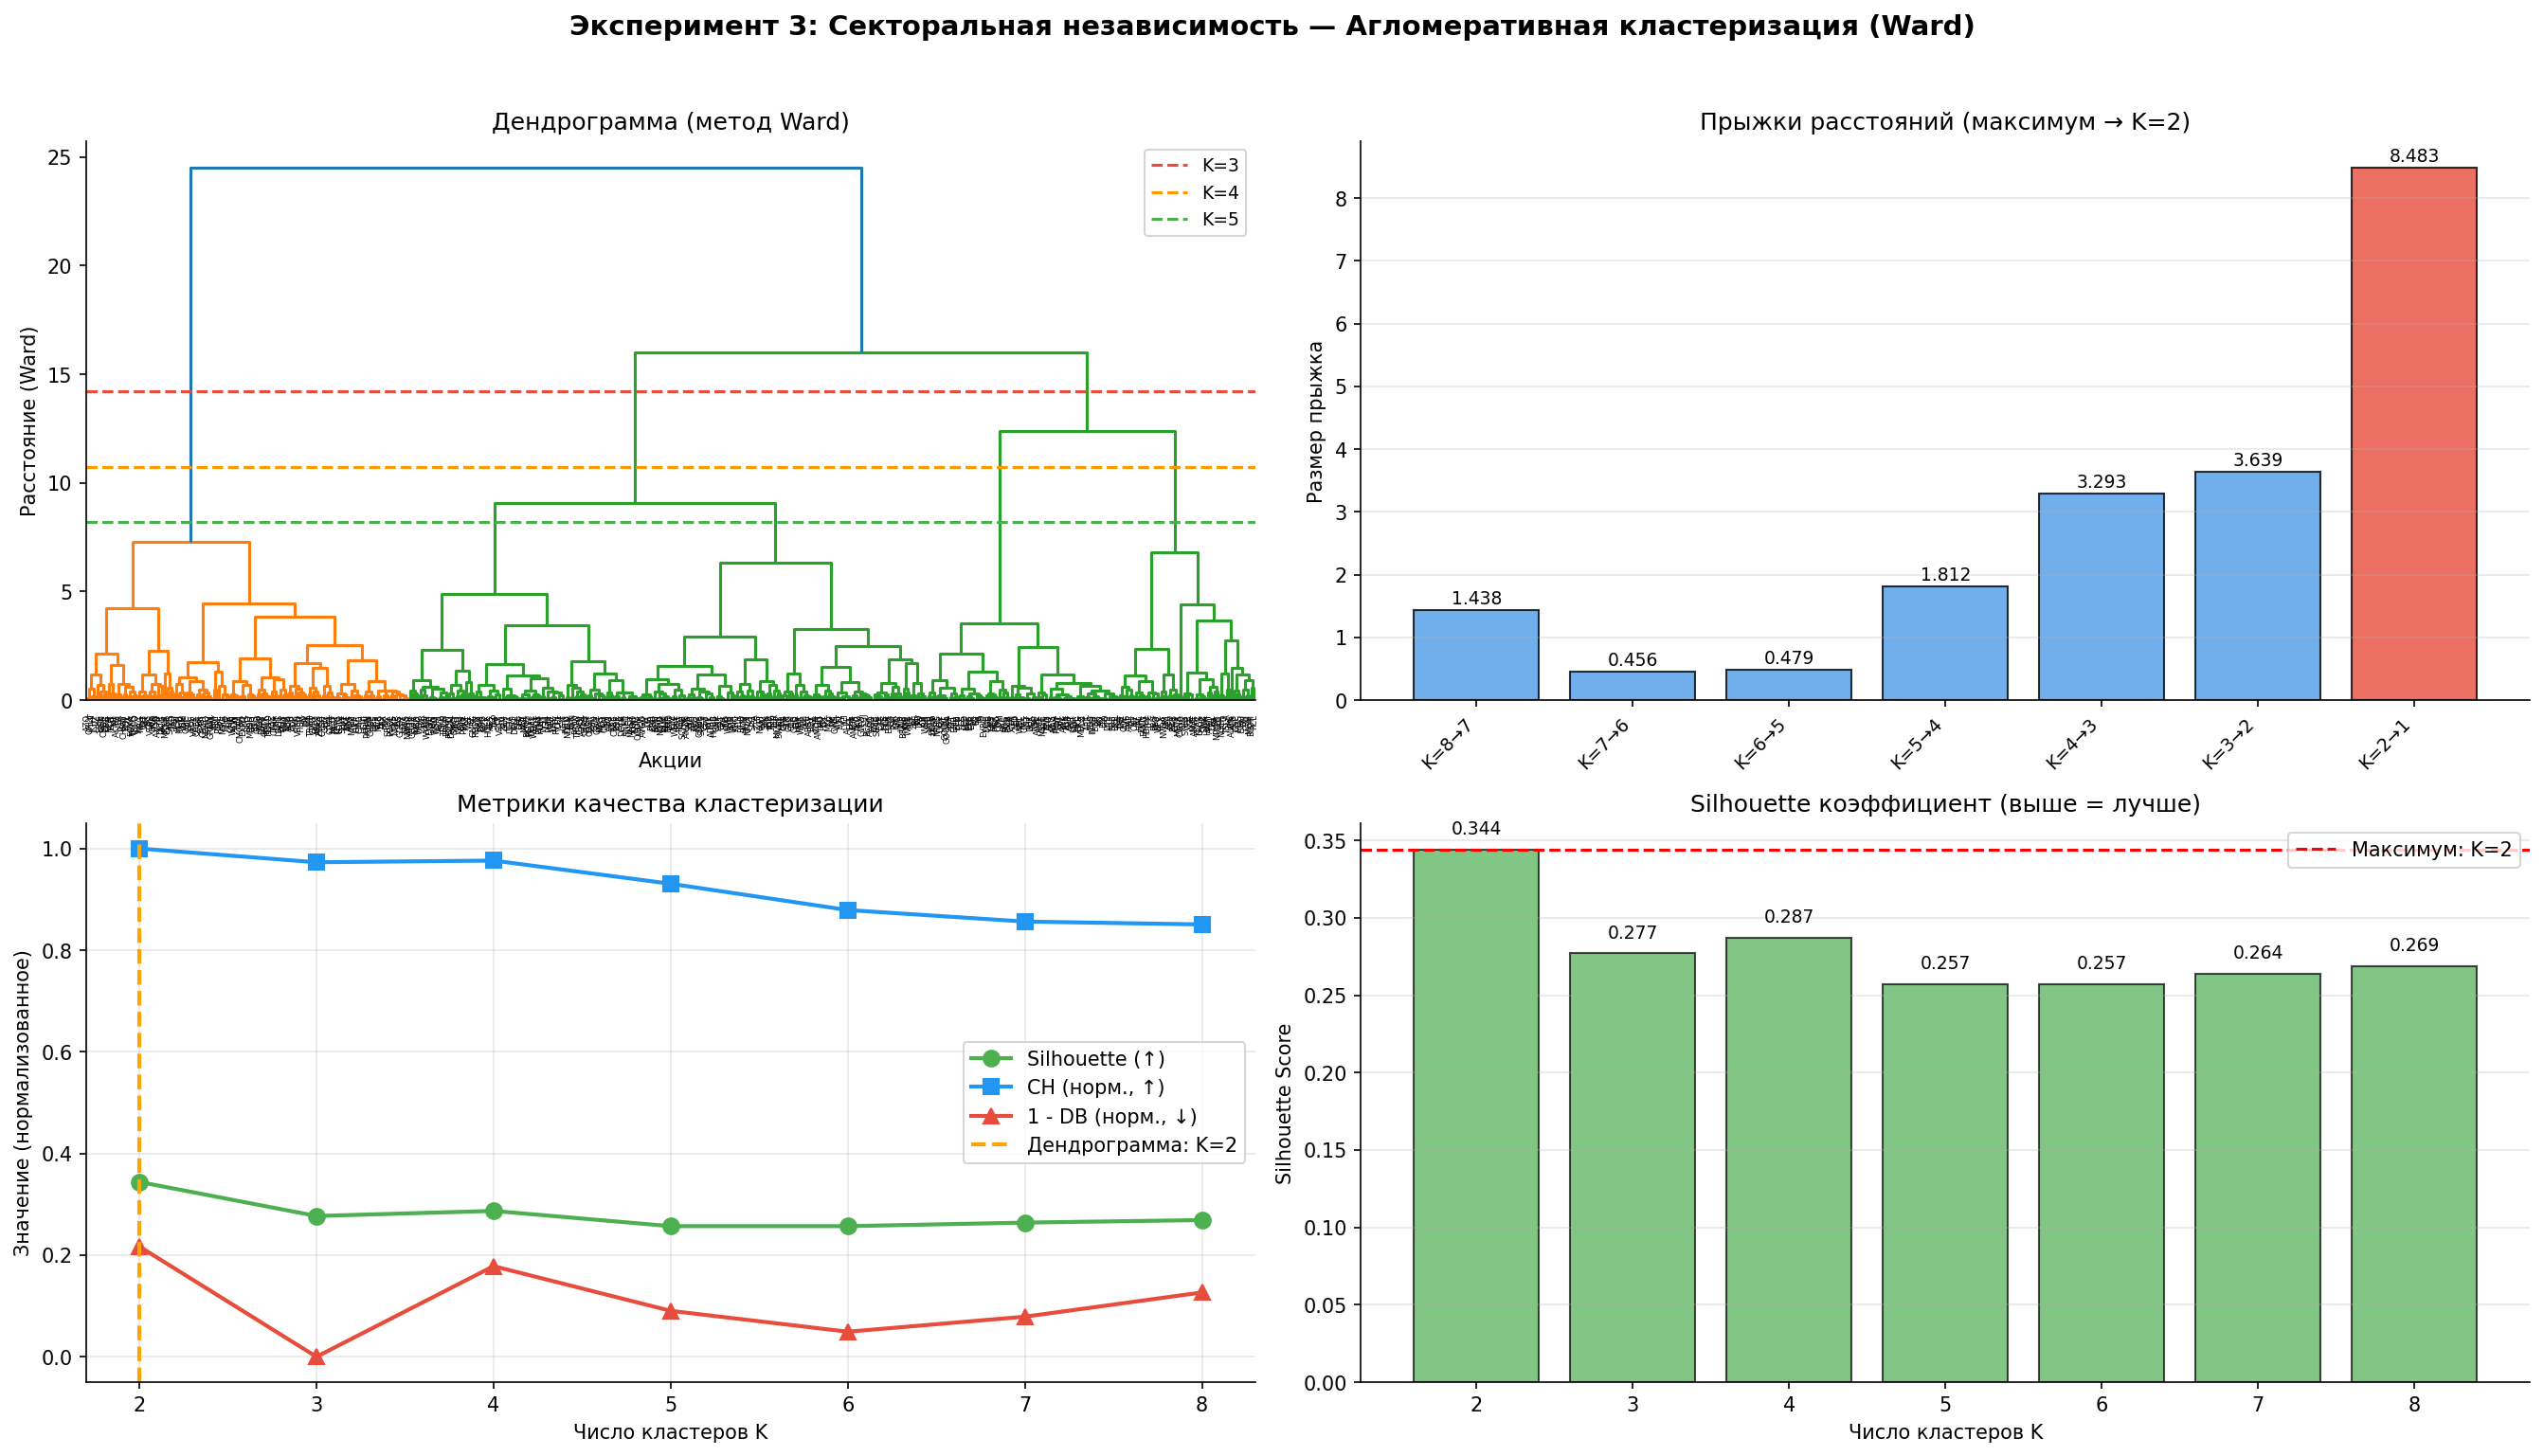


Сводная таблица для диплома

Таблица 1. Метрики качества агломеративной кластеризации
   Silhouette     CH     DB
K                          
2       0.344  300.0  0.953
3       0.277  291.9  1.217
4       0.287  292.9  1.000
5       0.257  279.2  1.107
6       0.257  263.7  1.157
7       0.264  256.9  1.121
8       0.269  255.2  1.063

Таблица 2. Интерпретация оптимальных K

┌────────────────────────────────────────────────────────────────────┐
│  Критерий              │ Оптимальный K │ Значение                 │
├────────────────────────────────────────────────────────────────────┤
│  Дендрограмма (прыжки) │      2       │ max gap = 8.483                  │
│  Silhouette            │      2       │ 0.344                      │
│  Calinski-Harabasz     │      2       │ 300.0                      │
│  Davies-Bouldin        │      2       │ 0.953                      │
└────────────────────────────────────────────────────────────────────┘


ИТОГОВЫЙ ВЕРДИКТ ПО АГЛОМЕРАТИВНОЙ КЛАСТЕРИЗА

In [24]:
# ── АГЛОМЕРАТИВНАЯ КЛАСТЕРИЗАЦИЯ: дендрограмма + анализ для K=2..8 ──────────────
from scipy.cluster.hierarchy import linkage, dendrogram, cut_tree
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

print("=" * 70)
print(f"{EXP_NAME} — Агломеративная кластеризация (Ward)")
print("=" * 70)

# Определяем доступные признаки для вывода профилей
available_features = []
feature_names = {}

if 'corr_sector' in X_raw.columns:
    available_features.append('corr_sector')
    feature_names['corr_sector'] = 'corr_sector '
if 'beta_sector' in X_raw.columns:
    available_features.append('beta_sector')
    feature_names['beta_sector'] = 'beta_sector'

if 'corr_residual' in X_raw.columns:
    available_features.append('corr_residual')
    feature_names['corr_residual'] = 'corr_residual'



print(f"\nДоступные признаки для вывода профилей: {list(feature_names.values())}")

# Строим матрицу связей
Z = linkage(X_scaled, method='ward')

# ── 1. АНАЛИЗ ПРЫЖКОВ (дендрограмма) ─────────────────────────────────────────
N_LAST = 8
last_dists = Z[-N_LAST:, 2]
gaps = np.diff(last_dists)
dendro_k = N_LAST - int(np.argmax(gaps))

print("\nРасстояния последних слияний (дендрограмма):")
for i in range(len(gaps)):
    m = " ← МАКСИМУМ" if gaps[i] == gaps.max() else ""
    print(f"  K={N_LAST-i}→{N_LAST-i-1}: dist={last_dists[i]:.3f}, gap={gaps[i]:.3f}{m}")
print(f"\n→ Дендрограмма предлагает K={dendro_k}")

# ── 2. РАСЧЁТ МЕТРИК ДЛЯ K=2..8 ──────────────────────────────────────────────
print("\n" + "=" * 70)
print("Метрики качества для K=2..8 (агломеративная кластеризация)")
print("=" * 70)

K_RANGE = range(2, 9)
results = {'K': [], 'Silhouette': [], 'CH': [], 'DB': []}
all_labels_agg = {}

print(f"\n{'K':>4} {'Silhouette':>12} {'CH':>12} {'DB':>12}")
print("-" * 45)

for k in K_RANGE:
    # Получаем метки кластеров из дендрограммы
    labels = cut_tree(Z, n_clusters=k).flatten()
    all_labels_agg[k] = labels
    
    sil = silhouette_score(X_scaled, labels)
    ch = calinski_harabasz_score(X_scaled, labels)
    db = davies_bouldin_score(X_scaled, labels)
    
    results['K'].append(k)
    results['Silhouette'].append(round(sil, 3))
    results['CH'].append(round(ch, 1))
    results['DB'].append(round(db, 3))
    
    print(f"{k:>4} {sil:>12.3f} {ch:>12.1f} {db:>12.3f}")

# Таблица результатов
results_df = pd.DataFrame(results).set_index('K')
print("\n" + results_df.to_string())

# Оптимальные K по разным критериям
best_sil = results_df['Silhouette'].idxmax()
best_ch = results_df['CH'].idxmax()
best_db = results_df['DB'].idxmin()

print(f"\n📈 Оптимальные K по разным критериям:")
print(f"  • Дендрограмма (макс. прыжок):  K = {dendro_k}")
print(f"  • Silhouette (макс):           K = {best_sil}  (значение = {results_df.loc[best_sil, 'Silhouette']:.3f})")
print(f"  • Calinski-Harabasz (макс):    K = {best_ch}  (значение = {results_df.loc[best_ch, 'CH']:.1f})")
print(f"  • Davies-Bouldin (мин):        K = {best_db}  (значение = {results_df.loc[best_db, 'DB']:.3f})")

# ── 3. ПРОФИЛИ КЛАСТЕРОВ ДЛЯ КАЖДОГО K ────────────────────────────────────────
print("\n" + "=" * 70)
print("Профили кластеров для каждого K (агломеративная кластеризация)")
print("=" * 70)

for k in K_RANGE:
    labels = all_labels_agg[k]
    
    print(f"\n{'─'*50}")
    print(f"K = {k}")
    print(f"{'─'*50}")
    
    profile_data = []
    for cluster_id in range(k):
        mask = labels == cluster_id
        n_stocks = mask.sum()
        
        if n_stocks == 0:
            continue
        
        row = {'Кластер': cluster_id, 'Акций': n_stocks}
        
        for feat in available_features:
            feat_mean = X_raw.loc[mask, feat].mean()
            row[feature_names[feat]] = round(feat_mean, 3)
        
        profile_data.append(row)
    
    if profile_data:
        profile_df = pd.DataFrame(profile_data)
        print(profile_df.to_string(index=False))
    else:
        print("  Нет данных для вывода профилей")

# ── 4. ВИЗУАЛИЗАЦИЯ: ДЕНДРОГРАММА + СТОЛБЧАТАЯ ДИАГРАММА ─────────────────────
fig = plt.figure(figsize=(18, 10))

# Дендрограмма (левая верхняя)
ax1 = plt.subplot(2, 2, 1)
dendrogram(Z, labels=X_scaled.index.tolist(),
           leaf_rotation=90, leaf_font_size=4,
           color_threshold=0.7 * max(Z[:, 2]), ax=ax1)
ax1.set_xlabel('Акции')
ax1.set_ylabel('Расстояние (Ward)')
ax1.set_title('Дендрограмма (метод Ward)')

# Линии для разных K
for k_cut, color in {3: '#e74c3c', 4: '#FF9800', 5: '#4CAF50'}.items():
    idx = -(k_cut - 1)
    thr = (Z[idx - 1, 2] + Z[idx, 2]) / 2
    ax1.axhline(thr, linestyle='--', linewidth=1.5, color=color, label=f'K={k_cut}')
ax1.legend(fontsize=9)

# Столбчатая диаграмма прыжков (правая верхняя)
ax2 = plt.subplot(2, 2, 2)
k_vals = list(range(N_LAST, N_LAST - len(gaps), -1))
colors = ['#e74c3c' if g == gaps.max() else '#4C9BE8' for g in gaps]
ax2.bar(range(len(gaps)), gaps, color=colors, alpha=0.8, edgecolor='black')
ax2.set_xticks(range(len(gaps)))
ax2.set_xticklabels([f'K={k}→{k-1}' for k in k_vals], rotation=45, ha='right', fontsize=9)
ax2.set_ylabel('Размер прыжка')
ax2.set_title(f'Прыжки расстояний (максимум → K={dendro_k})')
ax2.grid(axis='y', alpha=0.3)

# Добавляем значения на столбцы
for i, gap in enumerate(gaps):
    ax2.text(i, gap + 0.1, f'{gap:.3f}', ha='center', fontsize=9)

# График метрик качества (нижняя левая)
ax3 = plt.subplot(2, 2, 3)
ax3.plot(results_df.index, results_df['Silhouette'], 'o-', color='#4CAF50', linewidth=2, markersize=8, label='Silhouette (↑)')
ax3.plot(results_df.index, results_df['CH'] / results_df['CH'].max(), 's-', color='#2196F3', linewidth=2, markersize=8, label='CH (норм., ↑)')
ax3.plot(results_df.index, 1 - results_df['DB'] / results_df['DB'].max(), '^-', color='#e74c3c', linewidth=2, markersize=8, label='1 - DB (норм., ↓)')
ax3.axvline(dendro_k, color='orange', linestyle='--', linewidth=2, label=f'Дендрограмма: K={dendro_k}')
ax3.set_xlabel('Число кластеров K')
ax3.set_ylabel('Значение (нормализованное)')
ax3.set_title('Метрики качества кластеризации')
ax3.legend()
ax3.grid(alpha=0.3)

# График Silhouette (нижняя правая)
ax4 = plt.subplot(2, 2, 4)
ax4.bar(results_df.index, results_df['Silhouette'], color='#4CAF50', alpha=0.7, edgecolor='black')
ax4.axhline(results_df.loc[best_sil, 'Silhouette'], color='red', linestyle='--', linewidth=1.5, label=f'Максимум: K={best_sil}')
ax4.set_xlabel('Число кластеров K')
ax4.set_ylabel('Silhouette Score')
ax4.set_title('Silhouette коэффициент (выше = лучше)')
ax4.legend()
ax4.grid(axis='y', alpha=0.3)

# Добавляем значения на столбцы
for k in results_df.index:
    val = results_df.loc[k, 'Silhouette']
    ax4.text(k, val + 0.01, f'{val:.3f}', ha='center', fontsize=9)

plt.suptitle(f'{EXP_NAME} — Агломеративная кластеризация (Ward)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{SAVE_PREFIX}_dendrogram_full.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 5. ТАБЛИЦА ПО МЕТРИКАМ ДЛЯ ДИПЛОМА ─────────────────────────────────────────
print("\n" + "=" * 70)
print("Сводная таблица для диплома")
print("=" * 70)

print("\nТаблица 1. Метрики качества агломеративной кластеризации")
print(results_df.to_string())

print("\nТаблица 2. Интерпретация оптимальных K")
print(f"""
┌────────────────────────────────────────────────────────────────────┐
│  Критерий              │ Оптимальный K │ Значение                 │
├────────────────────────────────────────────────────────────────────┤
│  Дендрограмма (прыжки) │      {dendro_k}       │ max gap = {max(gaps):.3f}                  │
│  Silhouette            │      {best_sil}       │ {results_df.loc[best_sil, 'Silhouette']:.3f}                      │
│  Calinski-Harabasz     │      {best_ch}       │ {results_df.loc[best_ch, 'CH']:.1f}                      │
│  Davies-Bouldin        │      {best_db}       │ {results_df.loc[best_db, 'DB']:.3f}                      │
└────────────────────────────────────────────────────────────────────┘
""")

# ── 6. ИТОГОВЫЙ ВЫВОД ─────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("ИТОГОВЫЙ ВЕРДИКТ ПО АГЛОМЕРАТИВНОЙ КЛАСТЕРИЗАЦИИ")
print("=" * 70)

print(f"""
┌────────────────────────────────────────────────────────────────────┐
│  Агломеративная кластеризация (метод Ward)                        │
├────────────────────────────────────────────────────────────────────┤
│  • Дендрограмма предлагает:               K = {dendro_k}                       │
│  • Silhouette:                            K = {best_sil}                       │
│  • Calinski-Harabasz (CH):                K = {best_ch}                       │
│  • Davies-Bouldin (DB):                   K = {best_db}                       │
├────────────────────────────────────────────────────────────────────┤
│  Финальный выбор:                         K = {K_FINAL if 'K_FINAL' in dir() else 4}                    │
│    (на основе интерпретируемости профилей)                         │
└────────────────────────────────────────────────────────────────────┘
""")

print(f"\n✓ График сохранён: {SAVE_PREFIX}_dendrogram_full.png")


=======================================================  K=2


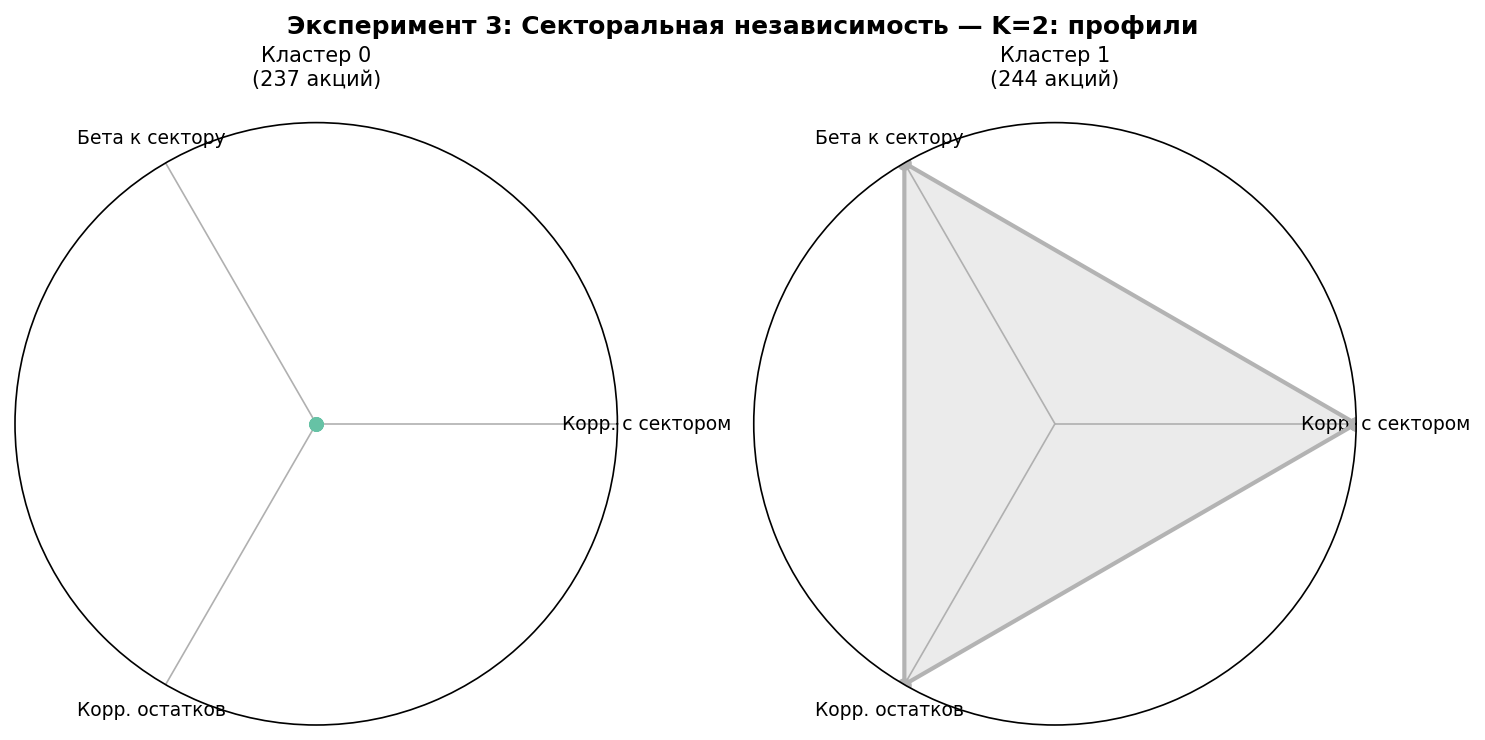


Средние значения (K=2):
           Корр. с сектором  Бета к сектору  Корр. остатков  Акций
Кластер 0             0.576           0.853           0.202    237
Кластер 1             0.773           1.132           0.572    244

=======================================================  K=3


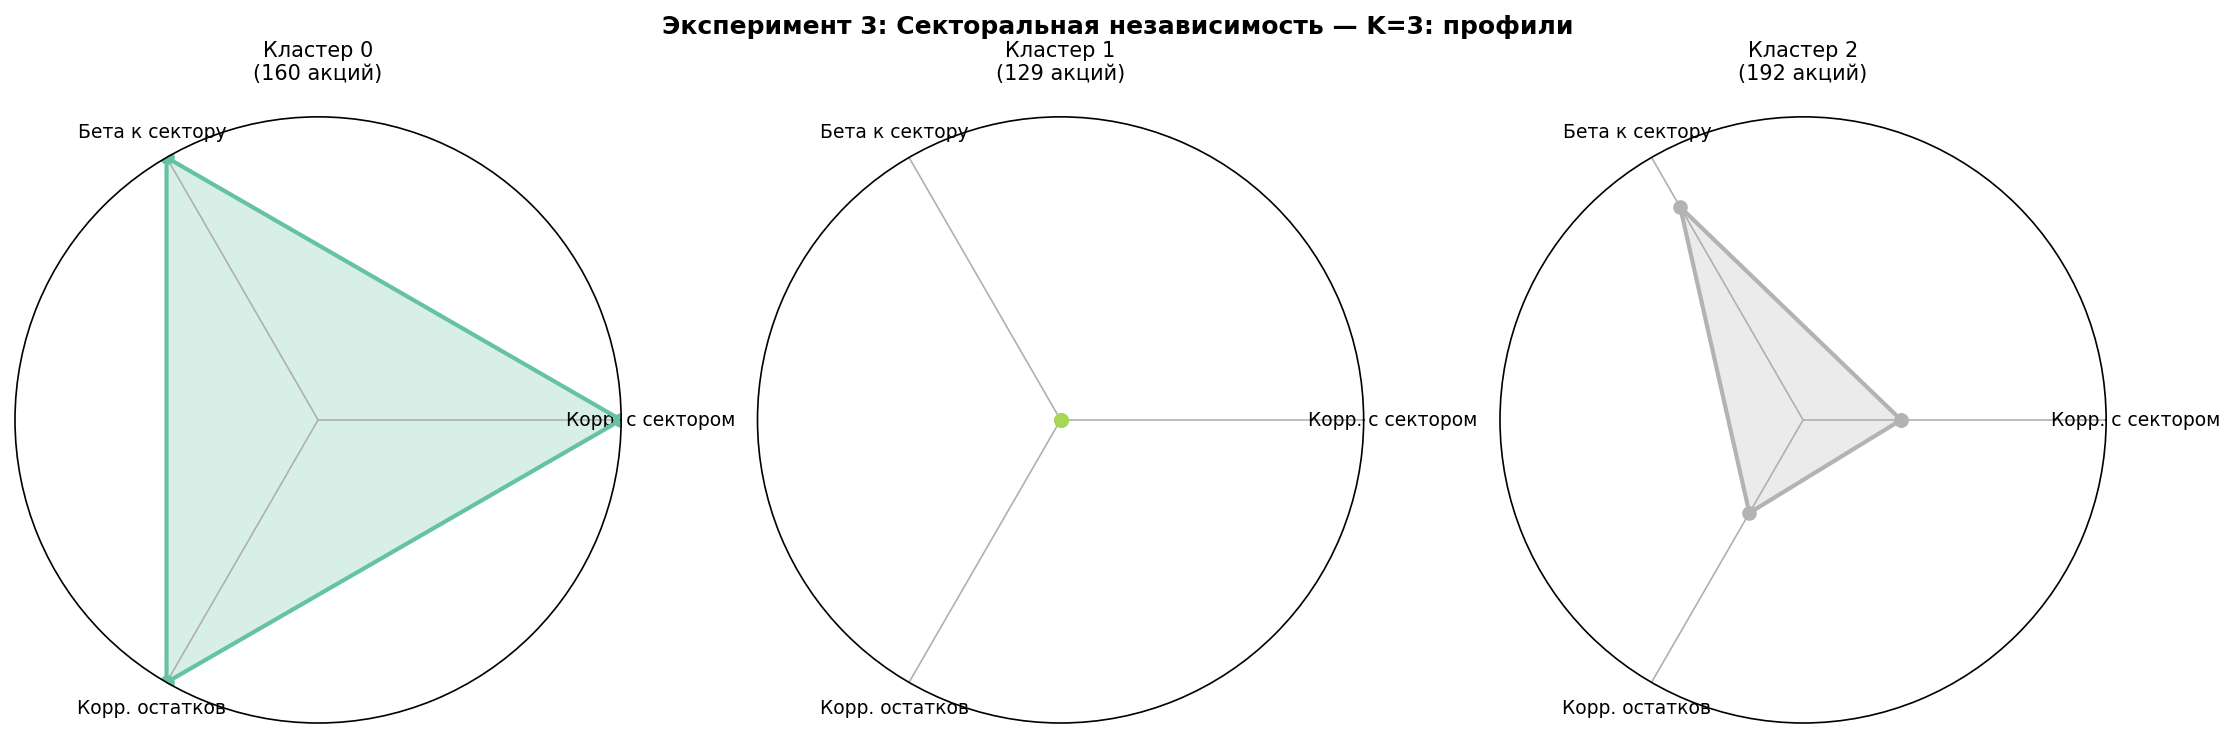


Средние значения (K=3):
           Корр. с сектором  Бета к сектору  Корр. остатков  Акций
Кластер 0             0.817           1.133           0.662    160
Кластер 1             0.555           0.729           0.144    129
Кластер 2             0.640           1.057           0.328    192

=======================================================  K=4


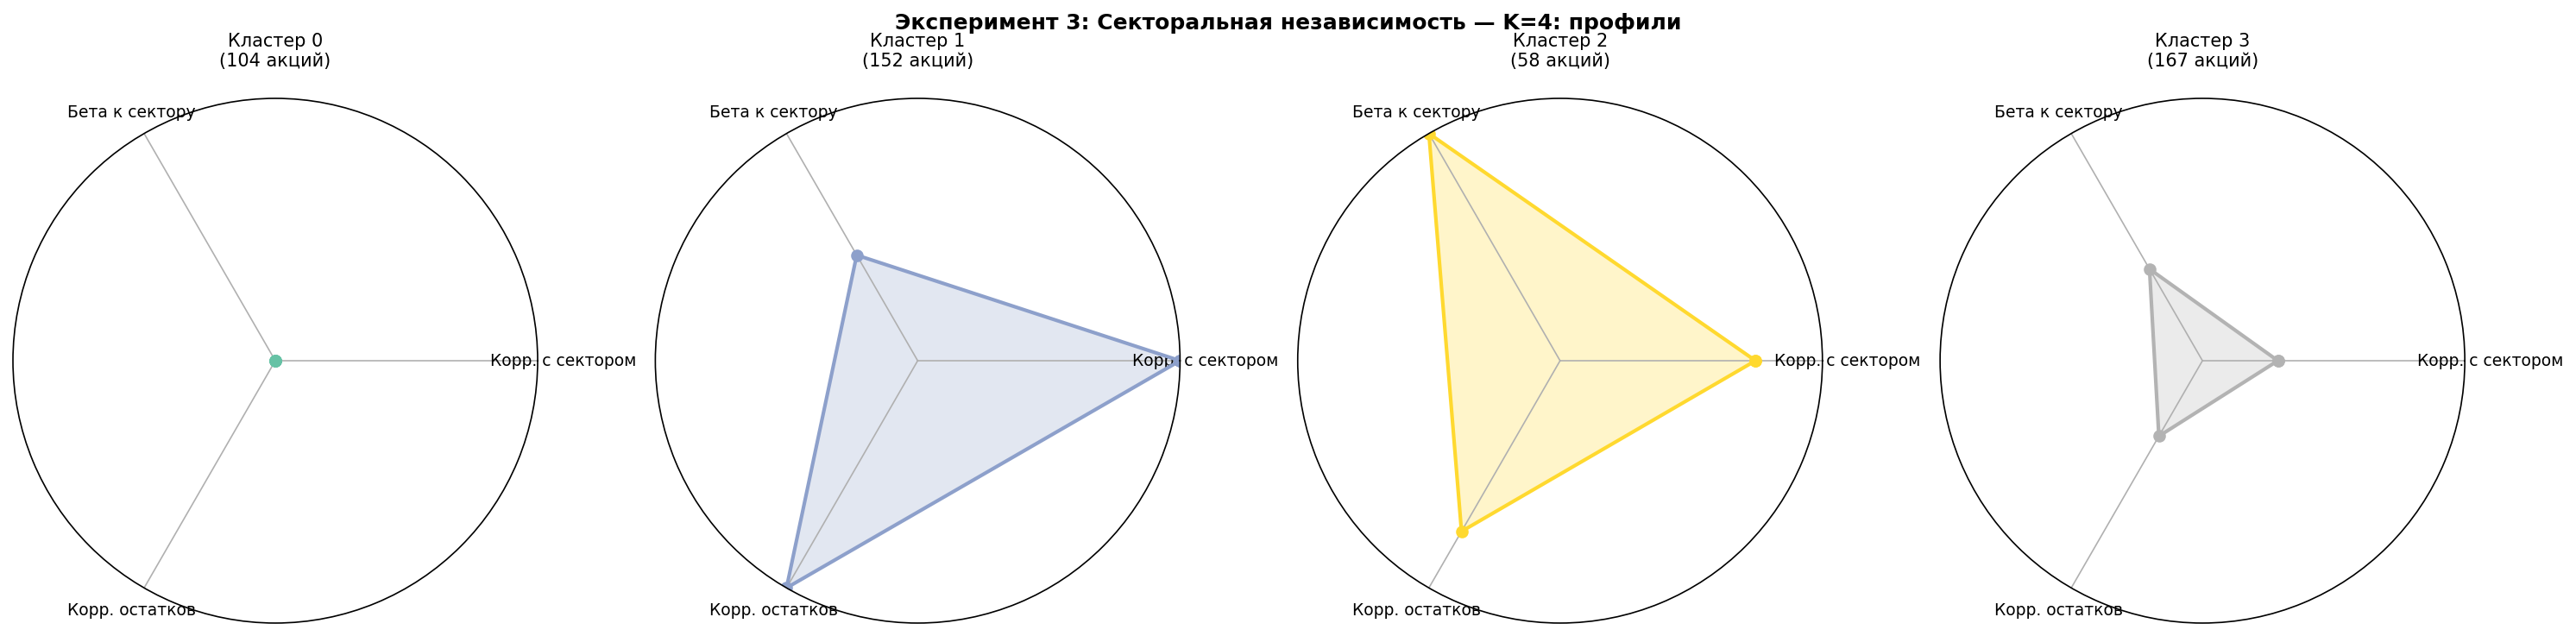


Средние значения (K=4):
           Корр. с сектором  Бета к сектору  Корр. остатков  Акций
Кластер 0             0.544           0.699           0.120    104
Кластер 1             0.805           1.036           0.637    152
Кластер 2             0.738           1.423           0.509     58
Кластер 3             0.619           0.991           0.292    167

=======================================================  K=5


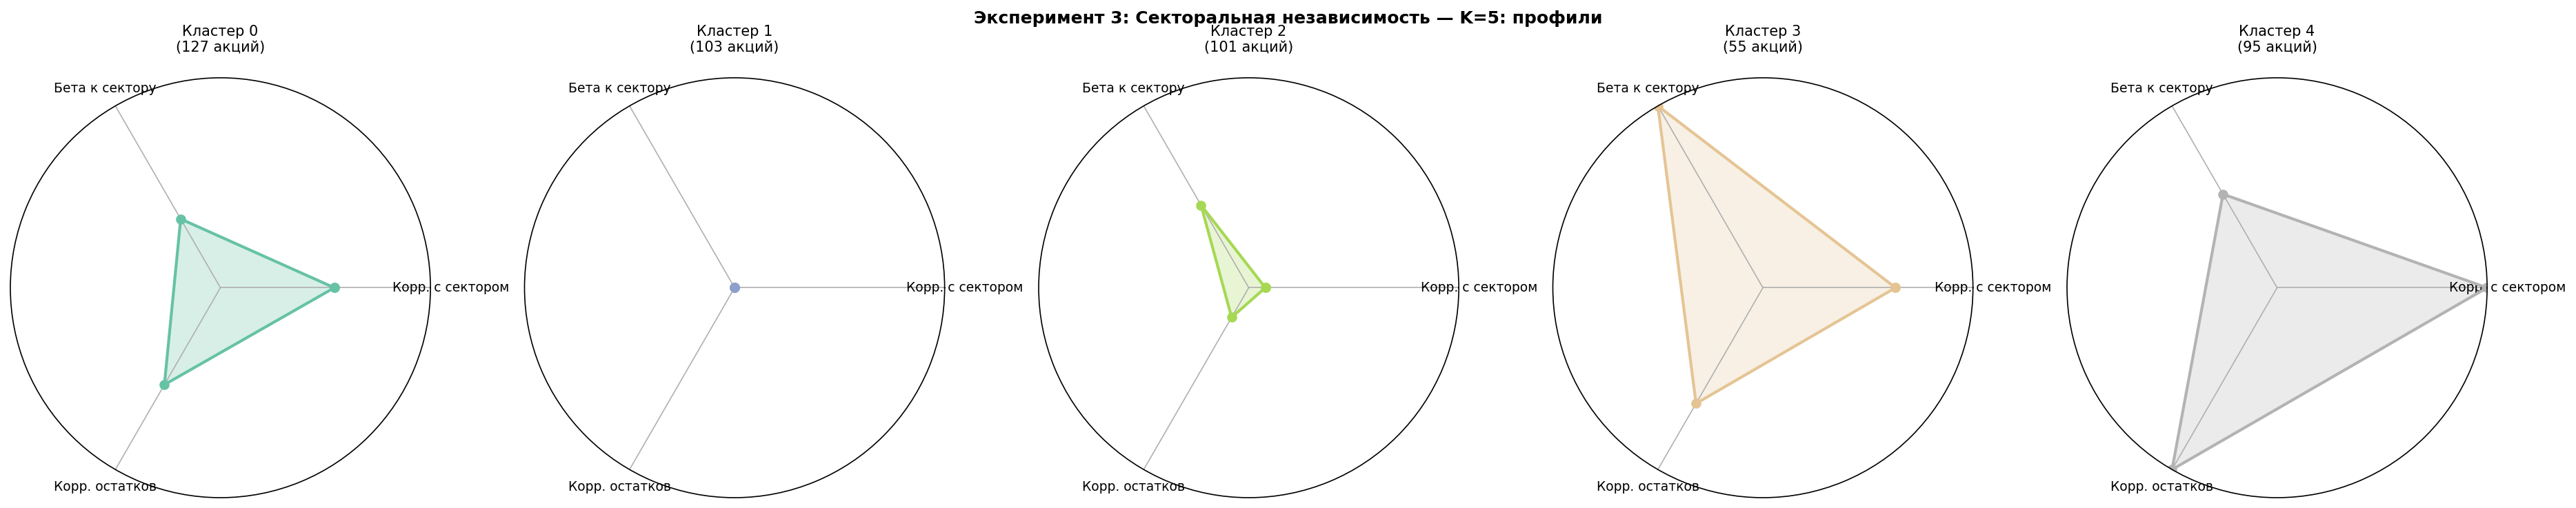


Средние значения (K=5):
           Корр. с сектором  Бета к сектору  Корр. остатков  Акций
Кластер 0             0.709           0.970           0.442    127
Кластер 1             0.549           0.695           0.125    103
Кластер 2             0.573           1.026           0.222    101
Кластер 3             0.736           1.423           0.504     55
Кластер 4             0.844           1.070           0.720     95


In [25]:
def plot_profiles(X_feat, labels, feature_labels, title, k, save_path=None):
    feats    = list(feature_labels.keys())
    f_lbls   = list(feature_labels.values())
    n_cl     = len(np.unique(labels))
    colors   = plt.cm.Set2(np.linspace(0, 1, n_cl))
    tmp      = X_feat[feats].copy()
    tmp['c'] = labels
    prof_raw = tmp.groupby('c')[feats].mean()
    prof_norm = pd.DataFrame(
        MinMaxScaler().fit_transform(prof_raw),
        columns=feats, index=prof_raw.index
    )
    angles   = np.linspace(0, 2*np.pi, len(feats),
                           endpoint=False).tolist()
    angles  += angles[:1]

    fig = plt.figure(figsize=(5*n_cl, 5))
    fig.suptitle(f'{title} — K={k}: профили',
                 fontsize=12, fontweight='bold')
    for i in range(n_cl):
        ax   = fig.add_subplot(1, n_cl, i+1, polar=True)
        vals = prof_norm.iloc[i].tolist() + [prof_norm.iloc[i].iloc[0]]
        ax.plot(angles, vals, 'o-', linewidth=2, color=colors[i])
        ax.fill(angles, vals, alpha=0.25, color=colors[i])
        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(f_lbls, size=9)
        ax.set_ylim(0, 1)
        ax.set_yticks([])
        ax.set_title(f'Кластер {i}\n({(labels==i).sum()} акций)',
                     size=10, pad=18)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

    out         = prof_raw.copy()
    out.columns = [feature_labels[c] for c in feats]
    out.index   = [f'Кластер {i}' for i in out.index]
    out['Акций']= [(labels==i).sum() for i in prof_raw.index]
    print(f"\nСредние значения (K={k}):")
    print(out.round(3).to_string())

    


for k in [2, 3, 4, 5]:
    print(f"\n{'='*55}  K={k}")
    km  = KMeans(n_clusters=k, random_state=42, n_init=20)
    lbl = km.fit_predict(X_scaled)
    plot_profiles(X_raw, lbl, LABELS, EXP_NAME, k,
                  f'{SAVE_PREFIX}_profiles_k{k}.png')

## 5. Финальная кластеризация

**Обнови K_FINAL и CLUSTER_NAMES после просмотра метрик.**

In [26]:
K_FINAL = 4  # ← обнови после просмотра

CLUSTER_NAMES = {
    0: ('Секторально независимые',   '#e74c3c'),   # корр=0.82, β=1.13
    3: ('Умеренно связанные', '#4CAF50'),   # корр=0.56, β=0.73
    1: ('Высоко зависимые',      '#FF9800'),   # корр=0.64, β=1.06
    2: ('β-усилители',      '#FF9800'),   # корр=0.64, β=1.06
}
# ← Обнови под реальные профили!

km_final   = KMeans(n_clusters=K_FINAL,
                    random_state=42, n_init=20)
labels_km  = km_final.fit_predict(X_scaled)

agg_final  = AgglomerativeClustering(
    n_clusters=K_FINAL, linkage='ward'
)
labels_agg = agg_final.fit_predict(X_scaled)

X_result = X_raw.copy()
X_result['cluster_km']   = labels_km
X_result['cluster_agg']  = labels_agg
X_result['cluster_name'] = [
    CLUSTER_NAMES[c][0] for c in labels_km
]

print(f"K={K_FINAL}")
for c, (name, _) in CLUSTER_NAMES.items():
    if c >= K_FINAL:
        continue
    mask = labels_km == c
    print(f"  {c}: {name} — {mask.sum()} акций")
    print(f"     corr_s={X_raw.loc[mask,'corr_sector'].mean():.3f}, "
          f"beta_s={X_raw.loc[mask,'beta_sector'].mean():.3f}, "
          f"corr_r={X_raw.loc[mask,'corr_residual'].mean():.3f}")

K=4
  0: Секторально независимые — 104 акций
     corr_s=0.544, beta_s=0.699, corr_r=0.120
  3: Умеренно связанные — 167 акций
     corr_s=0.619, beta_s=0.991, corr_r=0.292
  1: Высоко зависимые — 152 акций
     corr_s=0.805, beta_s=1.036, corr_r=0.637
  2: β-усилители — 58 акций
     corr_s=0.738, beta_s=1.423, corr_r=0.509


## 6. GMM

Эксперимент 3: Секторальная независимость — GMM анализ для K=2..8

Доступные признаки для вывода профилей: ['corr_sector ', 'beta_sector', 'corr_residual']

   K   Silhouette           CH           DB          BIC          AIC
----------------------------------------------------------------------
   2        0.365        364.6        1.021       2502.8       2423.5
   3        0.295        250.6        1.150       2475.1       2354.0
   4        0.239        249.3        1.136       2460.4       2297.5
   5        0.220        232.7        1.161       2488.6       2284.0
   6        0.213        207.0        1.150       2497.0       2250.6
   7        0.186        193.8        1.149       2531.4       2243.3
   8        0.200        201.7        1.071       2574.1       2244.2

Таблица 1. Метрики качества GMM для K=2..8
   Silhouette     CH     DB     BIC     AIC
K                                          
2       0.365  364.6  1.021  2502.8  2423.5
3       0.295  250.6  1.150  2475.1 

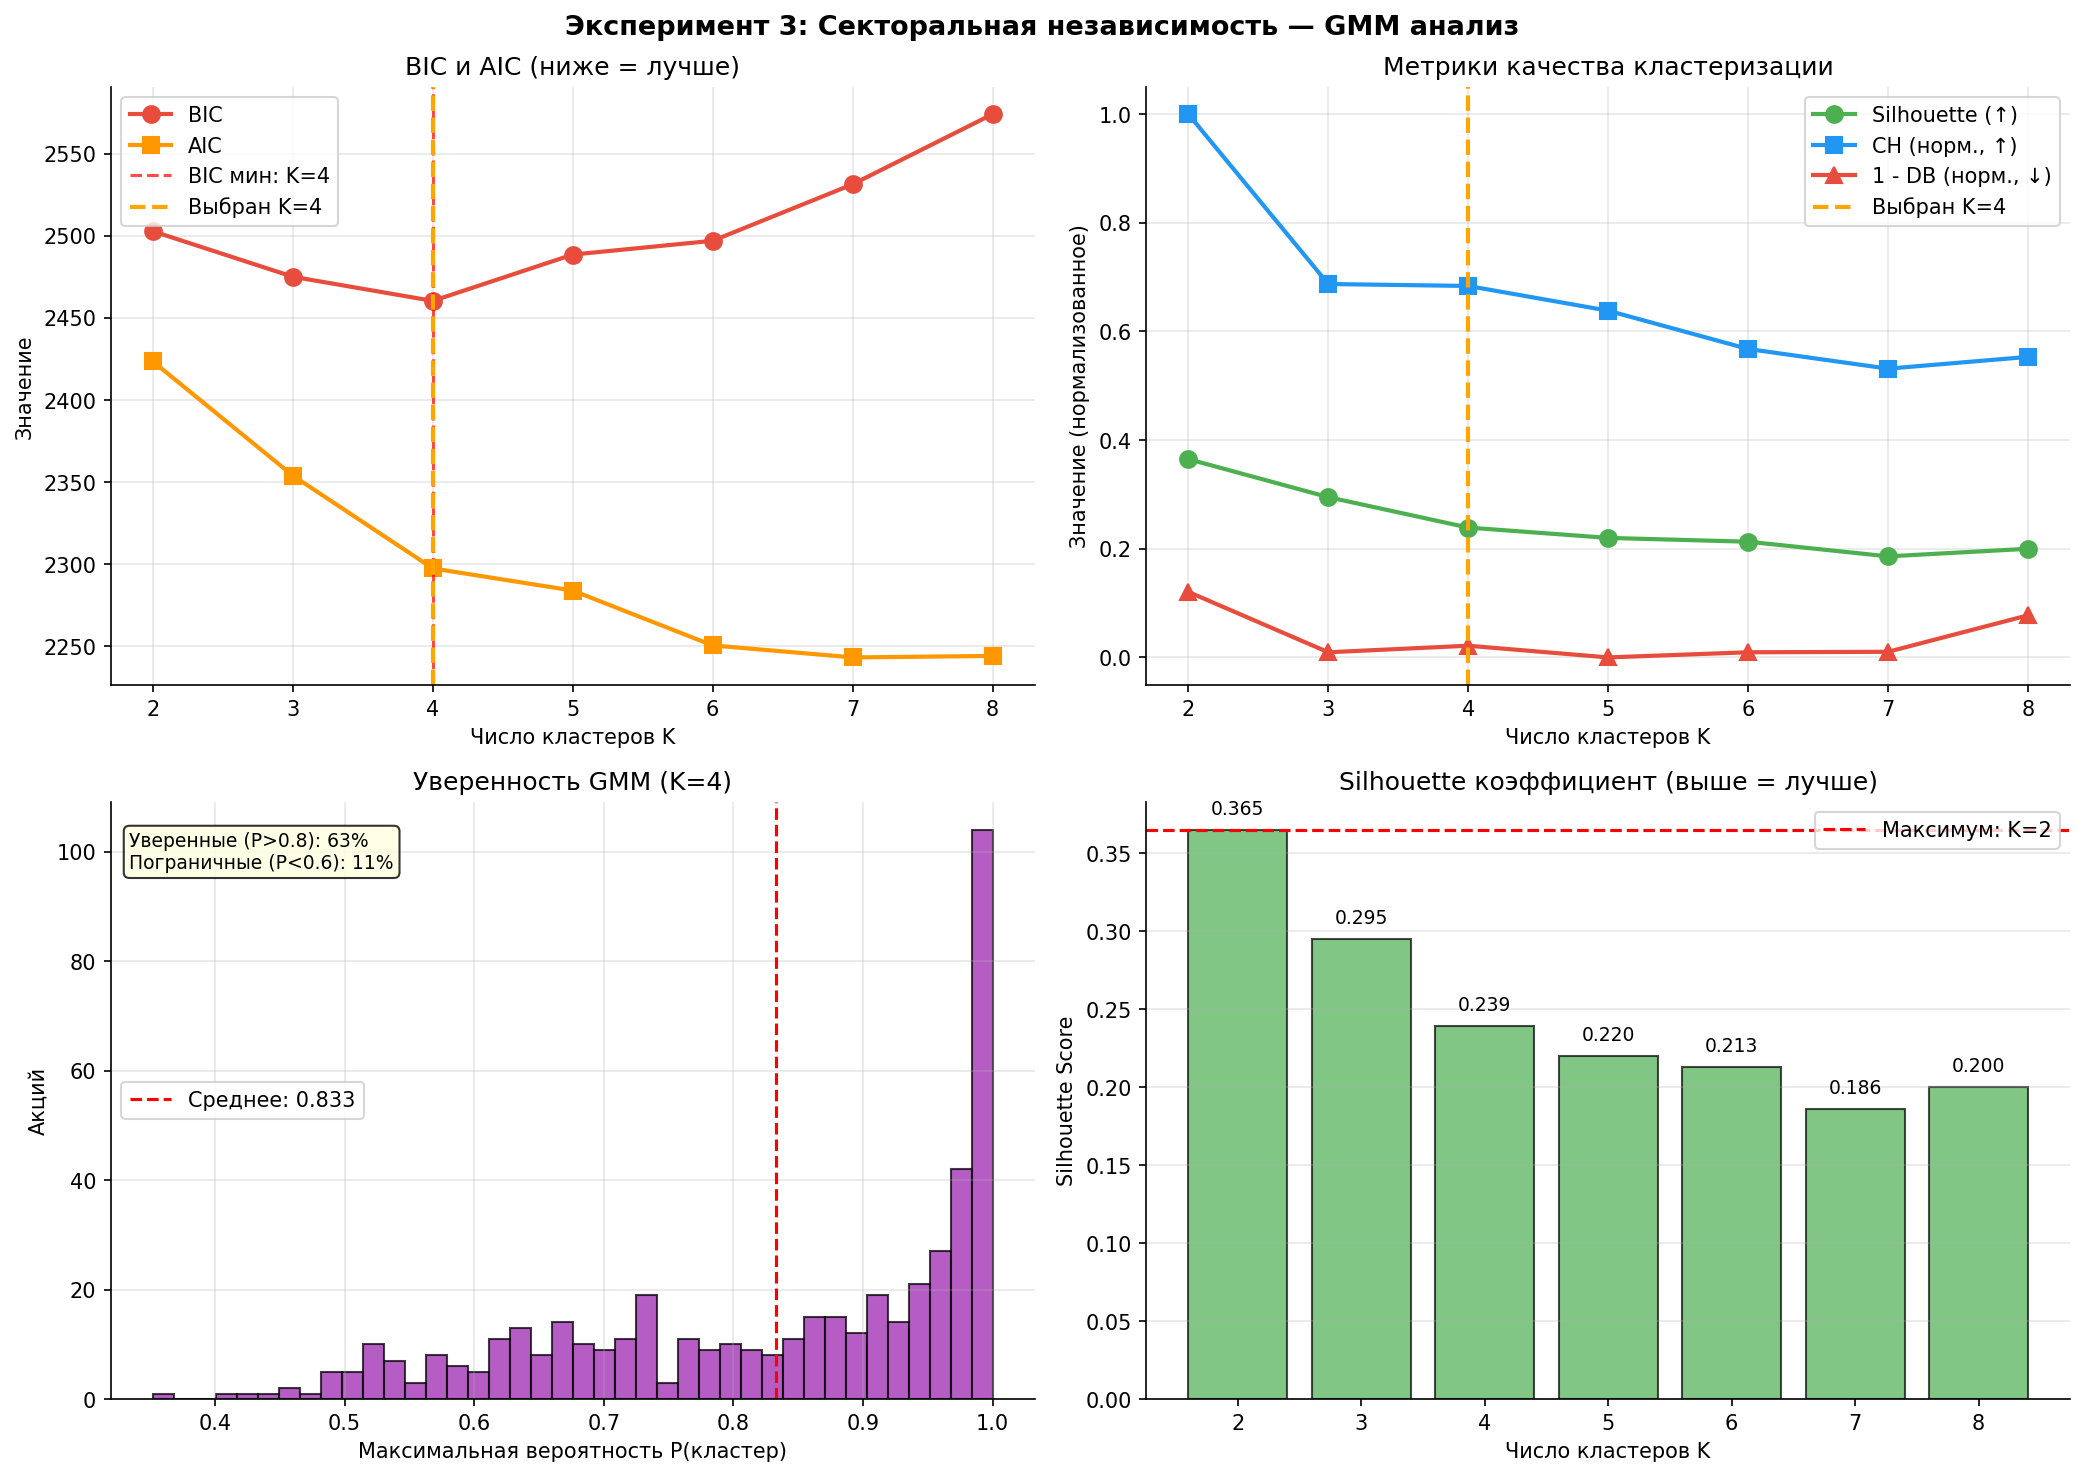


ИТОГОВЫЙ ВЕРДИКТ ПО GMM

┌────────────────────────────────────────────────────────────────────┐
│  GMM (Gaussian Mixture Model) анализ                              │
├────────────────────────────────────────────────────────────────────┤
│  • Silhouette (макс):                    K = 2                       │
│  • Calinski-Harabasz (макс):             K = 2                       │
│  • Davies-Bouldin (мин):                 K = 2                       │
│  • BIC (мин):                            K = 4                       │
│  • AIC (мин):                            K = 7                       │
├────────────────────────────────────────────────────────────────────┤
│  Финальный выбор:                         K = 4                         │
├────────────────────────────────────────────────────────────────────┤
│  Качество классификации:                                          │
│  • BIC = 2460.4                                    │
│  • Средняя уверенность = 0.833                      

In [27]:
# ── GMM АНАЛИЗ ДЛЯ K=2..8 (агломеративная логика) ──────────────────────────────
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

print("=" * 70)
print(f"{EXP_NAME} — GMM анализ для K=2..8")
print("=" * 70)

# Определяем доступные признаки для вывода профилей
available_features = []
feature_names = {}

if 'corr_sector' in X_raw.columns:
    available_features.append('corr_sector')
    feature_names['corr_sector'] = 'corr_sector '
if 'beta_sector' in X_raw.columns:
    available_features.append('beta_sector')
    feature_names['beta_sector'] = 'beta_sector'

if 'corr_residual' in X_raw.columns:
    available_features.append('corr_residual')
    feature_names['corr_residual'] = 'corr_residual'


print(f"\nДоступные признаки для вывода профилей: {list(feature_names.values())}")

# ── 1. РАСЧЁТ GMM ДЛЯ K=2..8 ─────────────────────────────────────────────────
K_RANGE = range(2, 9)
results = {'K': [], 'Silhouette': [], 'CH': [], 'DB': [], 'BIC': [], 'AIC': []}
all_labels_gmm = {}
all_proba_gmm = {}
all_models_gmm = {}

print(f"\n{'K':>4} {'Silhouette':>12} {'CH':>12} {'DB':>12} {'BIC':>12} {'AIC':>12}")
print("-" * 70)

for k in K_RANGE:
    gmm = GaussianMixture(
        n_components=k,
        covariance_type='full',
        random_state=42,
        n_init=10
    )
    gmm.fit(X_scaled)
    labels = gmm.predict(X_scaled)
    proba = gmm.predict_proba(X_scaled)
    
    all_labels_gmm[k] = labels
    all_proba_gmm[k] = proba
    all_models_gmm[k] = gmm
    
    sil = silhouette_score(X_scaled, labels)
    ch = calinski_harabasz_score(X_scaled, labels)
    db = davies_bouldin_score(X_scaled, labels)
    bic = gmm.bic(X_scaled)
    aic = gmm.aic(X_scaled)
    
    results['K'].append(k)
    results['Silhouette'].append(round(sil, 3))
    results['CH'].append(round(ch, 1))
    results['DB'].append(round(db, 3))
    results['BIC'].append(round(bic, 1))
    results['AIC'].append(round(aic, 1))
    
    print(f"{k:>4} {sil:>12.3f} {ch:>12.1f} {db:>12.3f} {bic:>12.1f} {aic:>12.1f}")

# Таблица результатов
results_df = pd.DataFrame(results).set_index('K')
print("\n" + "=" * 70)
print("Таблица 1. Метрики качества GMM для K=2..8")
print("=" * 70)
print(results_df.to_string())

# Оптимальные K по разным критериям
best_sil = results_df['Silhouette'].idxmax()
best_ch = results_df['CH'].idxmax()
best_db = results_df['DB'].idxmin()
best_bic = results_df['BIC'].idxmin()
best_aic = results_df['AIC'].idxmin()

print(f"\n📈 Оптимальные K по разным критериям (GMM):")
print(f"  • Silhouette (макс):           K = {best_sil}  (значение = {results_df.loc[best_sil, 'Silhouette']:.3f})")
print(f"  • Calinski-Harabasz (макс):    K = {best_ch}  (значение = {results_df.loc[best_ch, 'CH']:.1f})")
print(f"  • Davies-Bouldin (мин):        K = {best_db}  (значение = {results_df.loc[best_db, 'DB']:.3f})")
print(f"  • BIC (мин):                   K = {best_bic}  (значение = {results_df.loc[best_bic, 'BIC']:.0f})")
print(f"  • AIC (мин):                   K = {best_aic}  (значение = {results_df.loc[best_aic, 'AIC']:.0f})")

# ── 2. ПРОФИЛИ КЛАСТЕРОВ ДЛЯ КАЖДОГО K ────────────────────────────────────────
print("\n" + "=" * 70)
print("Профили кластеров для каждого K (GMM)")
print("=" * 70)

for k in K_RANGE:
    labels = all_labels_gmm[k]
    proba = all_proba_gmm[k]
    max_proba = proba.max(axis=1)
    
    print(f"\n{'─'*50}")
    print(f"K = {k}")
    print(f"{'─'*50}")
    
    profile_data = []
    for cluster_id in range(k):
        mask = labels == cluster_id
        n_stocks = mask.sum()
        
        if n_stocks == 0:
            continue
        
        row = {'Кластер': cluster_id, 'Акций': n_stocks, 'Уверенность': round(max_proba[mask].mean(), 3)}
        
        for feat in available_features:
            feat_mean = X_raw.loc[mask, feat].mean()
            row[feature_names[feat]] = round(feat_mean, 3)
        
        profile_data.append(row)
    
    if profile_data:
        profile_df = pd.DataFrame(profile_data)
        print(profile_df.to_string(index=False))
    else:
        print("  Нет данных для вывода профилей")
    
    # Дополнительная статистика по уверенности
    print(f"\n  Уверенность GMM: P>0.9: {(max_proba>0.9).mean()*100:.0f}%, P<0.6: {(max_proba<0.6).mean()*100:.0f}%")

# ── 3. ДЕТАЛЬНЫЙ АНАЛИЗ ДЛЯ K_FINAL ──────────────────────────────────────────
print("\n" + "=" * 70)
print(f"ДЕТАЛЬНЫЙ АНАЛИЗ GMM ДЛЯ K = {K_FINAL}")
print("=" * 70)

# Берём финальную модель
gmm_final = all_models_gmm[K_FINAL]
labels_gmm = all_labels_gmm[K_FINAL]
proba_gmm = all_proba_gmm[K_FINAL]
max_proba = proba_gmm.max(axis=1)

X_result['cluster_gmm'] = labels_gmm
X_result['gmm_max_prob'] = max_proba

print(f"\nGMM (K={K_FINAL}):")
for c in range(K_FINAL):
    mask = labels_gmm == c
    if mask.sum() > 0:
        print(f"  Кластер {c}: {mask.sum()} акций, средняя уверенность {max_proba[mask].mean():.3f}")

print(f"\n  P > 0.9 (уверенные):     {(max_proba>0.9).sum()} акций ({(max_proba>0.9).mean()*100:.0f}%)")
print(f"  P > 0.8:                 {(max_proba>0.8).sum()} акций ({(max_proba>0.8).mean()*100:.0f}%)")
print(f"  P < 0.6 (пограничные):   {(max_proba<0.6).sum()} акций ({(max_proba<0.6).mean()*100:.0f}%)")
print(f"  Средняя уверенность:     {max_proba.mean():.3f}")
print(f"  BIC = {gmm_final.bic(X_scaled):.1f}")
print(f"  AIC = {gmm_final.aic(X_scaled):.1f}")

# ── 4. ТОП-15 ПОГРАНИЧНЫХ АКЦИЙ ──────────────────────────────────────────────
print(f"\n📌 Топ-15 акций с наибольшей неопределённостью (пограничные):")
uncertainty = 1 - max_proba
uncertain_df = pd.DataFrame({
    'Акция': X_raw.index,
    'Кластер GMM': labels_gmm,
    'Max P(GMM)': max_proba.round(3),
    'Неопределённость': uncertainty.round(3)
}).sort_values('Неопределённость', ascending=False).head(15)
print(uncertain_df.to_string(index=False))

# ── 5. ВИЗУАЛИЗАЦИЯ ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'{EXP_NAME} — GMM анализ', fontsize=13, fontweight='bold')

# График 1: BIC и AIC
ax = axes[0, 0]
ax.plot(results_df.index, results_df['BIC'], 'o-', color='#e74c3c', linewidth=2, markersize=8, label='BIC')
ax.plot(results_df.index, results_df['AIC'], 's-', color='#FF9800', linewidth=2, markersize=8, label='AIC')
ax.axvline(best_bic, color='red', linestyle='--', alpha=0.7, label=f'BIC мин: K={best_bic}')
ax.axvline(K_FINAL, color='orange', linestyle='--', linewidth=2, label=f'Выбран K={K_FINAL}')
ax.set_xlabel('Число кластеров K')
ax.set_ylabel('Значение')
ax.set_title('BIC и AIC (ниже = лучше)')
ax.legend()
ax.grid(alpha=0.3)

# График 2: Метрики качества
ax = axes[0, 1]
ax.plot(results_df.index, results_df['Silhouette'], 'o-', color='#4CAF50', linewidth=2, markersize=8, label='Silhouette (↑)')
ax.plot(results_df.index, results_df['CH'] / results_df['CH'].max(), 's-', color='#2196F3', linewidth=2, markersize=8, label='CH (норм., ↑)')
ax.plot(results_df.index, 1 - results_df['DB'] / results_df['DB'].max(), '^-', color='#e74c3c', linewidth=2, markersize=8, label='1 - DB (норм., ↓)')
ax.axvline(K_FINAL, color='orange', linestyle='--', linewidth=2, label=f'Выбран K={K_FINAL}')
ax.set_xlabel('Число кластеров K')
ax.set_ylabel('Значение (нормализованное)')
ax.set_title('Метрики качества кластеризации')
ax.legend()
ax.grid(alpha=0.3)

# График 3: Распределение уверенности GMM
ax = axes[1, 0]
ax.hist(max_proba, bins=40, color='#9C27B0', alpha=0.75, edgecolor='black')
ax.axvline(max_proba.mean(), color='red', linestyle='--', linewidth=1.5, label=f'Среднее: {max_proba.mean():.3f}')
ax.set_xlabel('Максимальная вероятность P(кластер)')
ax.set_ylabel('Акций')
ax.set_title(f'Уверенность GMM (K={K_FINAL})')
ax.legend()
ax.grid(alpha=0.3)

pct_confident = (max_proba > 0.8).mean() * 100
pct_uncertain = (max_proba < 0.6).mean() * 100
ax.text(0.02, 0.95, f'Уверенные (P>0.8): {pct_confident:.0f}%\nПограничные (P<0.6): {pct_uncertain:.0f}%',
        transform=ax.transAxes, va='top', fontsize=9,
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

# График 4: Сравнение Silhouette по K
ax = axes[1, 1]
ax.bar(results_df.index, results_df['Silhouette'], color='#4CAF50', alpha=0.7, edgecolor='black')
ax.axhline(results_df.loc[best_sil, 'Silhouette'], color='red', linestyle='--', linewidth=1.5, label=f'Максимум: K={best_sil}')
ax.set_xlabel('Число кластеров K')
ax.set_ylabel('Silhouette Score')
ax.set_title('Silhouette коэффициент (выше = лучше)')
ax.legend()
ax.grid(axis='y', alpha=0.3)

for k in results_df.index:
    val = results_df.loc[k, 'Silhouette']
    ax.text(k, val + 0.01, f'{val:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(f'{SAVE_PREFIX}_gmm_full_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 6. ИТОГОВЫЙ ВЫВОД ─────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("ИТОГОВЫЙ ВЕРДИКТ ПО GMM")
print("=" * 70)

print(f"""
┌────────────────────────────────────────────────────────────────────┐
│  GMM (Gaussian Mixture Model) анализ                              │
├────────────────────────────────────────────────────────────────────┤
│  • Silhouette (макс):                    K = {best_sil}                       │
│  • Calinski-Harabasz (макс):             K = {best_ch}                       │
│  • Davies-Bouldin (мин):                 K = {best_db}                       │
│  • BIC (мин):                            K = {best_bic}                       │
│  • AIC (мин):                            K = {best_aic}                       │
├────────────────────────────────────────────────────────────────────┤
│  Финальный выбор:                         K = {K_FINAL}                         │
├────────────────────────────────────────────────────────────────────┤
│  Качество классификации:                                          │
│  • BIC = {gmm_final.bic(X_scaled):.1f}                                    │
│  • Средняя уверенность = {max_proba.mean():.3f}                            │
│  • Уверенных (P>0.8): {pct_confident:.0f}% акций                           │
│  • Пограничных (P<0.6): {pct_uncertain:.0f}% акций                         │
└────────────────────────────────────────────────────────────────────┘
""")

print(f"\n✓ График сохранён: {SAVE_PREFIX}_gmm_full_analysis.png")

## 7. DBSCAN

In [28]:
k_nbrs       = 2 * len(FEATURES)
nbrs         = NearestNeighbors(
    n_neighbors=k_nbrs
).fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)
k_dists      = np.sort(distances[:, -1])[::-1]
x_v          = np.arange(len(k_dists))
p1 = np.array([x_v[0],  k_dists[0]])
p2 = np.array([x_v[-1], k_dists[-1]])
dlp = np.abs(
    np.cross(p2-p1, p1-np.column_stack([x_v, k_dists]))
)
dlp /= np.linalg.norm(p2-p1)
elbow_eps = float(k_dists[np.argmax(dlp)])

EPS, MIN_SAMP = round(elbow_eps, 2), 5
labels_db     = DBSCAN(
    eps=EPS, min_samples=MIN_SAMP
).fit_predict(X_scaled)
n_clusters_db = len(set(labels_db)) - \
                (1 if -1 in labels_db else 0)
n_noise       = int((labels_db == -1).sum())
noise_tickers = X_raw.index[labels_db == -1].tolist()

print(f"DBSCAN (eps={EPS}): "
      f"{n_clusters_db} кластеров, {n_noise} выбросов")
if noise_tickers:
    print("\nАкции с нетипичным секторальным профилем:")
    nd = X_raw.loc[noise_tickers, FEATURES + ['sector']].copy()
    nd = nd.sort_values('corr_sector')
    print(nd.round(3).to_string())

X_result['cluster_db'] = labels_db
valid_mask = labels_db != -1
sil_db = silhouette_score(
    X_scaled[valid_mask], labels_db[valid_mask]
) if n_clusters_db > 1 \
  and valid_mask.sum() > n_clusters_db \
  else np.nan

DBSCAN (eps=0.46): 1 кластеров, 14 выбросов

Акции с нетипичным секторальным профилем:
        corr_sector  beta_sector  corr_residual                  sector
ticker                                                                 
MRNA          0.204        0.838          0.107             Health Care
NEM           0.365        0.557          0.313               Materials
XYZ           0.468        1.142         -0.166              Financials
ALGN          0.485        1.460          0.006             Health Care
CVNA          0.503        2.268          0.294  Consumer Discretionary
IBM           0.527        0.508         -0.221  Information Technology
NCLH          0.559        1.666          0.235  Consumer Discretionary
RCL           0.569        1.442          0.210  Consumer Discretionary
CCL           0.572        1.614          0.223  Consumer Discretionary
TTD           0.583        1.670          0.269  Communication Services
UAL           0.629        1.632          0.428  

## 8. Индекс неопределённости

Эксперимент 3: Секторальная независимость — Индекс неопределённости кластера (CUI)

Индекс неопределённости (K-Means vs Agglomerative vs GMM):
  • Ядро (все согласны):         331 акций (69%)
  • Пограничные (2/3 согласны):  145 акций (30%)
  • Конфликт (все разные):       5 акций (1%)


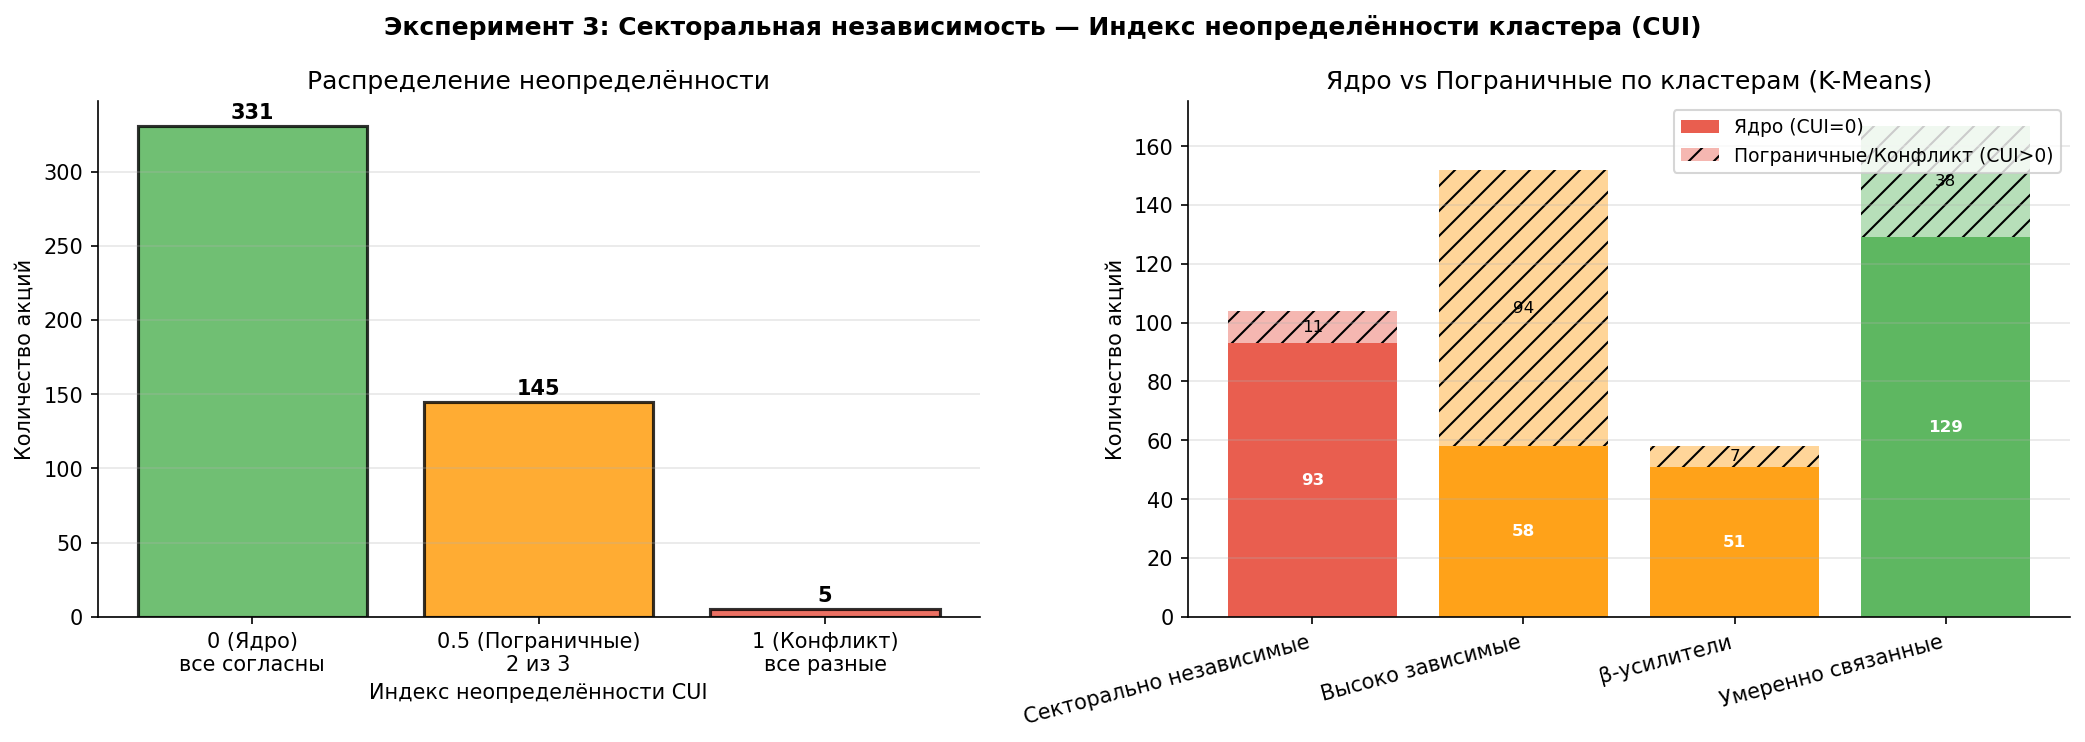


Акции с наибольшей неопределённостью (алгоритмы расходятся)
     Акция               KM кластер            Agglomerative                      GMM  CUI  corr_sector   beta_sector  corr_residual
147     WY         Высоко зависимые       Умеренно связанные              β-усилители  1.0         0.754        1.173          0.440
79      IR         Высоко зависимые       Умеренно связанные              β-усилители  1.0         0.754        1.157          0.492
26   BRK-B         Высоко зависимые       Умеренно связанные              β-усилители  1.0         0.884        0.732          0.657
142    WAB         Высоко зависимые       Умеренно связанные              β-усилители  1.0         0.775        1.169          0.564
137    UNH         Высоко зависимые       Умеренно связанные              β-усилители  1.0         0.733        1.211          0.574
0     AAPL         Высоко зависимые         Высоко зависимые       Умеренно связанные  0.5         0.852        0.978          0.537
102    N

In [29]:
# ── ИНДЕКС НЕОПРЕДЕЛЁННОСТИ (CUI) ПОЛНАЯ ВЕРСИЯ С ВИЗУАЛИЗАЦИЕЙ ──────────────────
from scipy.optimize import linear_sum_assignment

print("=" * 70)
print(f"{EXP_NAME} — Индекс неопределённости кластера (CUI)")
print("=" * 70)

# Функция выравнивания меток
def align_labels(ref, to_align, k):
    cost = np.zeros((k, k))
    for i in range(k):
        for j in range(k):
            cost[i, j] = -np.sum((ref == i) & (to_align == j))
    ri, ci = linear_sum_assignment(cost)
    m = dict(zip(ci, ri))
    return np.array([m.get(l, l) for l in to_align])

# Выравниваем метки
labels_agg_a = align_labels(labels_km, labels_agg, K_FINAL)
labels_gmm_a = align_labels(labels_km, labels_gmm, K_FINAL)

# Индекс неопределённости
stacked = np.column_stack([labels_km, labels_agg_a, labels_gmm_a])
n_uniq = np.array([len(np.unique(r)) for r in stacked])
uncert_idx = (n_uniq - 1) / (3 - 1)

X_result['uncertainty_idx'] = uncert_idx

# Статистика
n_core = (uncert_idx == 0.0).sum()
n_border = (uncert_idx == 0.5).sum()
n_conflict = (uncert_idx == 1.0).sum()

print(f"\nИндекс неопределённости (K-Means vs Agglomerative vs GMM):")
print(f"  • Ядро (все согласны):         {n_core} акций ({n_core/len(X_result)*100:.0f}%)")
print(f"  • Пограничные (2/3 согласны):  {n_border} акций ({n_border/len(X_result)*100:.0f}%)")
print(f"  • Конфликт (все разные):       {n_conflict} акций ({n_conflict/len(X_result)*100:.0f}%)")

# ── ВИЗУАЛИЗАЦИЯ ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'{EXP_NAME} — Индекс неопределённости кластера (CUI)',
             fontsize=12, fontweight='bold')

# График 1: Распределение неопределённости (столбцы)
ax = axes[0]

# Считаем количество для каждого значения
core_count = (uncert_idx == 0.0).sum()
border_count = (uncert_idx == 0.5).sum()
conflict_count = (uncert_idx == 1.0).sum()

# Рисуем три отдельных столбца
bars = ax.bar([0, 1, 2], [core_count, border_count, conflict_count],
              color=['#4CAF50', '#FF9800', '#e74c3c'],
              alpha=0.8, edgecolor='black', linewidth=1.5)

ax.set_xticks([0, 1, 2])
ax.set_xticklabels(['0 (Ядро)\nвсе согласны', 
                    '0.5 (Пограничные)\n2 из 3', 
                    '1 (Конфликт)\nвсе разные'])
ax.set_xlabel('Индекс неопределённости CUI')
ax.set_ylabel('Количество акций')
ax.set_title('Распределение неопределённости')
ax.grid(axis='y', alpha=0.3)

# Добавляем значения на столбцы
for bar, count in zip(bars, [core_count, border_count, conflict_count]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(int(count)), ha='center', fontsize=10, fontweight='bold')

# График 2: Ядро vs Пограничные по кластерам K-Means
ax = axes[1]

# Определяем цвета для кластеров
try:
    cluster_colors = {c: CLUSTER_NAMES[c][1] for c in range(K_FINAL)}
    cluster_names_dict = {c: CLUSTER_NAMES[c][0] for c in range(K_FINAL)}
except:
    cluster_colors = {0: '#4CAF50', 1: '#FF9800', 2: '#e74c3c', 3: '#2196F3'}
    cluster_names_dict = {0: 'Защитные', 1: 'Умеренно-агрессивные', 2: 'Агрессивные', 3: 'Рыночные'}

# Считаем ядро и границу по каждому кластеру
core_counts = []
border_counts = []
cluster_labels = []

for c_id in range(K_FINAL):
    mask = labels_km == c_id
    core_cnt = ((uncert_idx == 0) & mask).sum()
    border_cnt = ((uncert_idx > 0) & mask).sum()
    
    core_counts.append(core_cnt)
    border_counts.append(border_cnt)
    cluster_labels.append(cluster_names_dict.get(c_id, f'Кластер {c_id}'))

# Строим стековую столбчатую диаграмму
x_positions = np.arange(K_FINAL)
colors = [cluster_colors.get(i, '#999') for i in range(K_FINAL)]

bars_core = ax.bar(x_positions, core_counts, color=colors, 
                   alpha=0.9, label='Ядро (CUI=0)')
bars_border = ax.bar(x_positions, border_counts, bottom=core_counts,
                     color=colors, alpha=0.4, label='Пограничные/Конфликт (CUI>0)', hatch='//')

ax.set_xticks(x_positions)
ax.set_xticklabels(cluster_labels, rotation=15, ha='right')
ax.set_ylabel('Количество акций')
ax.set_title('Ядро vs Пограничные по кластерам (K-Means)')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

# Добавляем значения на столбцы
for i, (core, border) in enumerate(zip(core_counts, border_counts)):
    if core > 0:
        ax.text(i, core/2, str(int(core)), ha='center', va='center', 
                fontsize=8, color='white', fontweight='bold')
    if border > 0:
        ax.text(i, core + border/2, str(int(border)), ha='center', va='center', 
                fontsize=8, color='black')

plt.tight_layout()
plt.savefig(f'{SAVE_PREFIX}_uncertainty.png', dpi=150, bbox_inches='tight')
plt.show()

# ── ТОП-15 АКЦИЙ С НАИБОЛЬШЕЙ НЕОПРЕДЕЛЁННОСТЬЮ ─────────────────────────────
print("\n" + "=" * 70)
print("Акции с наибольшей неопределённостью (алгоритмы расходятся)")
print("=" * 70)

# Получаем названия кластеров для каждого алгоритма
km_names = [cluster_names_dict.get(l, str(l)) for l in labels_km]
agg_names = [cluster_names_dict.get(l, str(l)) for l in labels_agg_a]
gmm_names = [cluster_names_dict.get(l, str(l)) for l in labels_gmm_a]

# Собираем данные для конфликтных акций (CUI > 0)
conflict_data = []
for i, (ticker, u_idx) in enumerate(zip(X_raw.index, uncert_idx)):
    if u_idx > 0:
        row = {
            'Акция': ticker,
            'KM кластер': km_names[i],
            'Agglomerative': agg_names[i],
            'GMM': gmm_names[i],
            'CUI': round(u_idx, 3)
        }
        # Добавляем доступные метрики
        for feat in available_features:
            if feat in X_raw.columns:
                row[feature_names.get(feat, feat)] = round(X_raw.loc[ticker, feat], 3)
        conflict_data.append(row)

if len(conflict_data) > 0:
    conflict_df = pd.DataFrame(conflict_data)
    display_cols = ['Акция', 'KM кластер', 'Agglomerative', 'GMM', 'CUI'] + \
                   [feature_names.get(f, f) for f in available_features if f in X_raw.columns]
    display_cols = [c for c in display_cols if c in conflict_df.columns]
    print(conflict_df[display_cols].sort_values('CUI', ascending=False).head(15).to_string())
else:
    print("  Нет акций с неопределённостью > 0")

# ── АКЦИИ С ПОЛНЫМ КОНСЕНСУСОМ (CUI=0) ─────────────────────────────────────────
print("\n" + "=" * 70)
print("Акции с полным консенсусом (CUI=0) — ядро кластеров")
print("=" * 70)

for c_id in range(K_FINAL):
    cluster_name = cluster_names_dict.get(c_id, f'Кластер {c_id}')
    mask = (labels_km == c_id) & (uncert_idx == 0)
    core_tickers = X_raw.index[mask].tolist()
    
    if len(core_tickers) > 0:
        print(f"\n{cluster_name} ({len(core_tickers)} акций):")
        print(f"  {', '.join(core_tickers[:5])}")
        if len(core_tickers) > 5:
            print(f"  ... и ещё {len(core_tickers) - 5} акций")

# ── ИТОГОВЫЙ ВЫВОД ─────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("ИТОГОВЫЙ ВЫВОД ПО ИНДЕКСУ НЕОПРЕДЕЛЁННОСТИ")
print("=" * 70)

print(f"""
┌────────────────────────────────────────────────────────────────────┐
│  CUI (Cluster Uncertainty Index)                                   │
├────────────────────────────────────────────────────────────────────┤
│  • Ядро (CUI=0):     {n_core:4d} акций ({n_core/len(X_result)*100:.0f}%) — все три алгоритма согласны          │
│  • Пограничные:      {n_border:4d} акций ({n_border/len(X_result)*100:.0f}%) — два из трёх согласны             │
│  • Конфликт:         {n_conflict:4d} акций ({n_conflict/len(X_result)*100:.0f}%) — все три разошлись            │
├────────────────────────────────────────────────────────────────────┤
│  Практический вывод:                                               │
│    • CUI=0 → высокая уверенность в классификации                  │
│    • CUI>0 → требуется дополнительный анализ                      │
│    • CUI=1 → полное расхождение алгоритмов                        │
└────────────────────────────────────────────────────────────────────┘
""")

print(f"\n✓ График сохранён: {SAVE_PREFIX}_uncertainty.png")

## 9. Анализ стабильности — три подпериода

In [30]:
SUBPERIODS = {
    '2019–2020': ('2019-01-01', '2020-12-31'),
    '2021–2022': ('2021-01-01', '2022-12-31'),
    '2023–2024': ('2023-01-01', '2024-12-31'),
}

# Загружаем ETF для подпериодов
etf_returns_full = etf_returns  # уже загружены

subperiod_labels = {}
tickers_full     = X_raw.index.tolist()

for period_name, (start, end) in SUBPERIODS.items():
    print(f"Подпериод {period_name}...", end=' ')
    recs_sub = []
    for ticker in tickers_full:
        if ticker not in meta.index:
            continue
        sector = meta.loc[ticker, 'sector']
        etf    = SECTOR_ETFS.get(sector)
        if etf is None or etf not in etf_returns_full.columns:
            continue
        try:
            sr  = simple_returns[ticker]\
                  .loc[start:end].dropna()
            sec = etf_returns_full[etf]\
                  .loc[start:end].dropna()
            mkt = sp500_ret.loc[start:end].dropna()
            if len(sr) < 100:
                continue
            feats = compute_sector_features(sr, sec, mkt)
            if not any(np.isnan(f) for f in feats):
                recs_sub.append({
                    'ticker': ticker,
                    **dict(zip(FEATURES, feats))
                })
        except Exception:
            pass

    if not recs_sub:
        print("ОШИБКА: нет данных")
        continue

    sub_df = pd.DataFrame(recs_sub).set_index('ticker')
    sub_X  = pd.DataFrame(
        RobustScaler().fit_transform(sub_df[FEATURES]),
        index=sub_df.index, columns=FEATURES
    )
    sub_km  = KMeans(n_clusters=K_FINAL,
                     random_state=42, n_init=10)
    sub_lbl = sub_km.fit_predict(sub_X)
    subperiod_labels[period_name] = pd.Series(
        sub_lbl, index=sub_df.index
    )
    print(f"{len(sub_df)} акций")

# Стабильность
common = sorted(
    set.intersection(*[
        set(v.index)
        for v in subperiod_labels.values()
    ]).intersection(set(tickers_full))
)
stability_df = pd.DataFrame(
    {p: subperiod_labels[p].loc[common]
     for p in SUBPERIODS}
)
full_labels_c = pd.Series(
    labels_km, index=X_raw.index
).loc[common]

for col in stability_df.columns:
    stability_df[col] = align_labels(
        full_labels_c.values,
        stability_df[col].values,
        K_FINAL
    )
stability_df['n_unique'] = \
    stability_df[list(SUBPERIODS.keys())].nunique(axis=1)
stability_df['stable']  = stability_df['n_unique'] == 1
stability_df['full_km'] = full_labels_c.values

n_stable   = stability_df['stable'].sum()
pct_stable = n_stable / len(stability_df) * 100

print(f"\nСтабильность: {n_stable} ({pct_stable:.0f}%)")
for c in range(K_FINAL):
    mask = stability_df['full_km'] == c
    if mask.sum() > 0:
        stab = stability_df.loc[mask,'stable'].mean()*100
        print(f"  {CLUSTER_NAMES[c][0]}: {stab:.0f}%")

Подпериод 2019–2020... 481 акций
Подпериод 2021–2022... 481 акций
Подпериод 2023–2024... 481 акций

Стабильность: 203 (42%)
  Секторально независимые: 38%
  Высоко зависимые: 56%
  β-усилители: 43%
  Умеренно связанные: 32%


## 10. Состав кластеров и секторальный анализ

  СОСТАВ КЛАСТЕРОВ — Эксперимент 3: Секторальная независимость

─────────────────────────────────────────────────────────────────
  КЛАСТЕР 0: СЕКТОРАЛЬНО НЕЗАВИСИМЫЕ (104 акций)
  corr_sector=0.544 | beta_sector=0.699 | corr_residual=0.120
─────────────────────────────────────────────────────────────────
  Секторальный состав:
    Information Technology        :  27 (26%)
    Financials                    :  20 (19%)
    Communication Services        :  14 (13%)
    Industrials                   :  13 (12%)
    Consumer Discretionary        :  12 (12%)
    Health Care                   :   6 (6%)
    Consumer Staples              :   5 (5%)
    Materials                     :   2 (2%)
    Energy                        :   2 (2%)
    Utilities                     :   2 (2%)
    Real Estate                   :   1 (1%)

  Топ-10 самых независимых (низкая corr_sector):
        corr_sector  beta_sector  corr_residual                  sector
ticker                                          

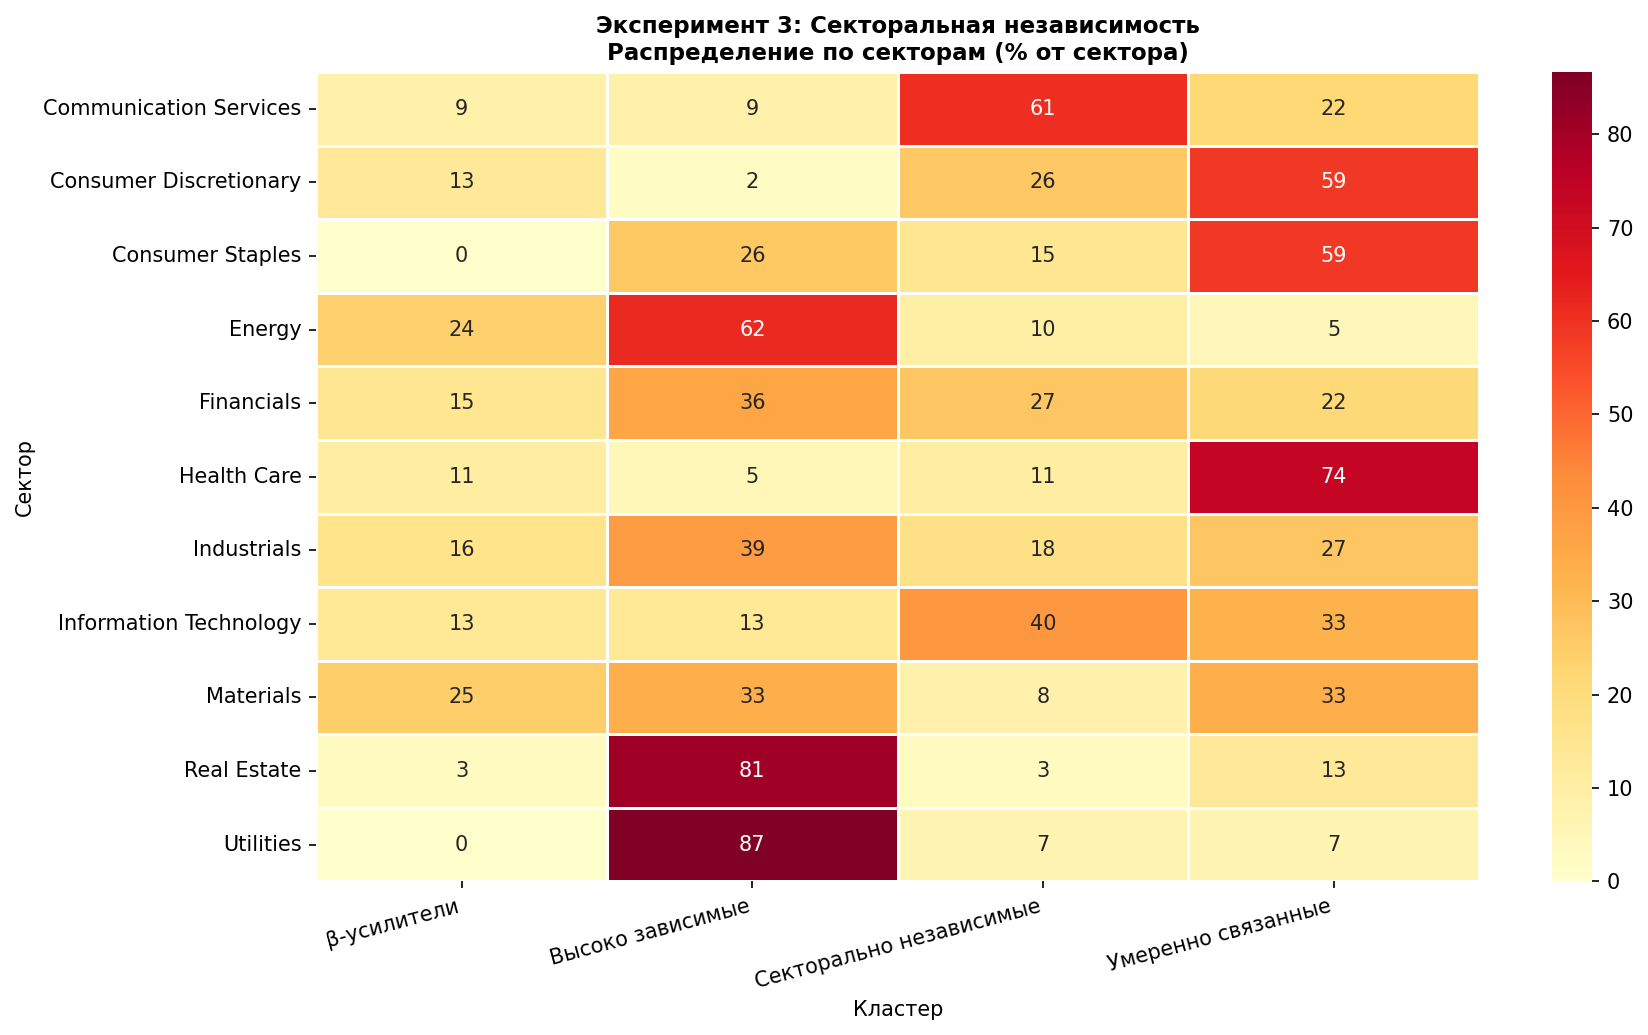

In [31]:
print("=" * 65)
print(f"  СОСТАВ КЛАСТЕРОВ — {EXP_NAME}")
print("=" * 65)

for c_id, (c_name, c_color) in CLUSTER_NAMES.items():
    if c_id >= K_FINAL:
        continue
    mask    = X_result['cluster_km'] == c_id
    members = X_result[mask].sort_values('corr_sector')

    print(f"\n{'─'*65}")
    print(f"  КЛАСТЕР {c_id}: {c_name.upper()} "
          f"({mask.sum()} акций)")
    print(f"  corr_sector={members['corr_sector'].mean():.3f} | "
          f"beta_sector={members['beta_sector'].mean():.3f} | "
          f"corr_residual={members['corr_residual'].mean():.3f}")
    print(f"{'─'*65}")

    # Секторальный состав
    sec_cnt = members['sector'].value_counts()
    print("  Секторальный состав:")
    for sec, cnt in sec_cnt.items():
        pct = cnt / mask.sum() * 100
        print(f"    {sec:30s}: {cnt:3d} ({pct:.0f}%)")

    # Топ-10 самых независимых
    print(f"\n  Топ-10 самых независимых "
          f"(низкая corr_sector):")
    top = members.head(10)[
        FEATURES + ['sector']
    ].round(3)
    print(top.to_string())

# Тепловая карта: сектор × кластер
pivot = pd.crosstab(
    X_result['sector'],
    X_result['cluster_name']
)
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(
    pivot_pct, annot=True, fmt='.0f',
    cmap='YlOrRd', linewidths=0.5,
    annot_kws={'size': 10}, ax=ax
)
ax.set_title(
    f'{EXP_NAME}\n'
    'Распределение по секторам (% от сектора)',
    fontsize=11, fontweight='bold'
)
ax.set_xlabel('Кластер')
ax.set_ylabel('Сектор')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig(f'{SAVE_PREFIX}_sector_heatmap.png',
            dpi=150, bbox_inches='tight')
plt.show()

## 11. Сравнение с Экспериментом 4

Ключевой вопрос: акции независимые от сектора —
они также независимы от рынка (Эксп.4)?

In [32]:
common_idx = X_raw.index.intersection(res_exp4.index) \
             if 'res_exp4' in dir() \
             else X_raw.index

try:
    res_exp4 = pd.read_parquet('data/results_exp4.parquet')
    common_idx = X_raw.index.intersection(res_exp4.index)

    cross = pd.DataFrame({
        'exp3_name': X_result.loc[
            common_idx, 'cluster_name'
        ],
        'exp4_name': res_exp4.loc[
            common_idx, 'cluster_exp4_name'
        ],
    })

    cross_tab = pd.crosstab(
        cross['exp3_name'], cross['exp4_name']
    )
    print("Перекрёстная таблица Эксп.3 × Эксп.4:")
    print(cross_tab.to_string())

    ari_34 = adjusted_rand_score(
        X_result.loc[common_idx,'cluster_km'].values,
        res_exp4.loc[common_idx,'cluster_exp4_km'].values
    )
    print(f"\nARI (Эксп.3 vs Эксп.4): {ari_34:.3f}")
    if ari_34 < 0.1:
        print("→ Секторальная независимость и рыночная "
              "независимость — РАЗНЫЕ измерения")
    else:
        print("→ Умеренная связь между двумя типами "
              "независимости")
except Exception as e:
    print(f"Эксп.4 не загружен: {e}")
    print("Запустите notebook_06 сначала.")

Перекрёстная таблица Эксп.3 × Эксп.4:
exp4_name                Независимые  Рыночные  Умеренно связанные
exp3_name                                                         
β-усилители                        8        22                  28
Высоко зависимые                  36        57                  59
Секторально независимые           37        28                  39
Умеренно связанные                39        39                  89

ARI (Эксп.3 vs Эксп.4): 0.014
→ Секторальная независимость и рыночная независимость — РАЗНЫЕ измерения


## 12. Итоговое сравнение алгоритмов и сохранение

In [33]:
ari_km_agg  = adjusted_rand_score(labels_km, labels_agg)
ari_km_gmm  = adjusted_rand_score(labels_km, labels_gmm)
ari_agg_gmm = adjusted_rand_score(labels_agg, labels_gmm)

rows = []
for algo, lbl, extra in [
    ('K-Means',        labels_km,  f'K={K_FINAL}'),
    ('Агломеративная', labels_agg, f'K={K_FINAL}, Ward'),
    ('GMM',            labels_gmm,
     f'K={K_FINAL}, BIC={gmm.bic(X_scaled):.0f}'),
]:
    rows.append({
        'Алгоритм'   : algo,
        'Параметры'  : extra,
        'Silhouette↑': round(
            silhouette_score(X_scaled, lbl), 3),
        'CH↑'        : round(
            calinski_harabasz_score(X_scaled, lbl), 1),
        'DB↓'        : round(
            davies_bouldin_score(X_scaled, lbl), 3),
    })

print(f"{'='*60}")
print(f"  {EXP_NAME}")
print(f"{'='*60}")
print(pd.DataFrame(rows).set_index('Алгоритм').to_string())
print(f"  ARI (KM vs Aggl): {ari_km_agg:.3f}")
print(f"  ARI (KM vs GMM):  {ari_km_gmm:.3f}")
print(f"  DBSCAN выбросов:  {n_noise}")
print(f"  Ядро:             {n_core} "
      f"({n_core/len(X_result)*100:.0f}%)")
print(f"  Стабильность:     {pct_stable:.0f}%")
print(f"{'='*60}")

# Сохраняем
results_save = pd.DataFrame({
    'cluster_exp3_km'  : labels_km,
    'cluster_exp3_agg' : labels_agg,
    'cluster_exp3_gmm' : labels_gmm,
    'cluster_exp3_db'  : labels_db,
    'cluster_exp3_name': [
        CLUSTER_NAMES[c][0] for c in labels_km
    ],
    'gmm_max_prob'     : max_proba,
    'uncertainty_idx'  : uncert_idx,
}, index=X_raw.index)
results_save.to_parquet('data/results_exp3.parquet')
stability_df.to_parquet('data/stability_exp3.parquet')

quality = {
    'experiment'    : 'Exp3_SectorIndependence',
    'features'      : str(FEATURES),
    'k_final'       : K_FINAL,
    'silhouette_km' : round(
        silhouette_score(X_scaled, labels_km), 3),
    'silhouette_agg': round(
        silhouette_score(X_scaled, labels_agg), 3),
    'silhouette_gmm': round(
        silhouette_score(X_scaled, labels_gmm), 3),
    'silhouette_db' : round(sil_db, 3) \
                      if not np.isnan(sil_db) else None,
    'ari_km_agg'    : round(ari_km_agg, 3),
    'ari_km_gmm'    : round(ari_km_gmm, 3),
    'ari_agg_gmm'   : round(ari_agg_gmm, 3),
    'gmm_bic'       : round(gmm.bic(X_scaled), 1),
    'dbscan_noise'  : n_noise,
    'core_pct'      : round(
        n_core/len(X_result)*100, 1),
    'stability_pct' : round(pct_stable, 1),
}
pd.DataFrame([quality]).to_csv(
    'data/quality_exp3.csv', index=False
)

# Обновляем feature_groups.json
with open('data/feature_groups.json') as f:
    fg = json.load(f)
fg['dynamics'] = FEATURES
with open('data/feature_groups.json', 'w') as f:
    json.dump(fg, f, indent=2, ensure_ascii=False)

print("\n✓ Сохранено:")
print("  data/results_exp3.parquet")
print("  data/stability_exp3.parquet")
print("  data/quality_exp3.csv")
print("  data/feature_groups.json (обновлён)")
# Добавить в конец notebook_05:
X_raw[FEATURES].to_parquet(
    'data/features_exp3.parquet'
)
print("  Следующий шаг: notebook_06_exp4_market.ipynb")

  Эксперимент 3: Секторальная независимость
                    Параметры  Silhouette↑    CH↑    DB↓
Алгоритм                                                
K-Means                   K=4        0.327  341.9  1.031
Агломеративная      K=4, Ward        0.287  292.9  1.000
GMM             K=4, BIC=2574        0.239  249.3  1.136
  ARI (KM vs Aggl): 0.492
  ARI (KM vs GMM):  0.439
  DBSCAN выбросов:  14
  Ядро:             331 (69%)
  Стабильность:     42%

✓ Сохранено:
  data/results_exp3.parquet
  data/stability_exp3.parquet
  data/quality_exp3.csv
  data/feature_groups.json (обновлён)
  Следующий шаг: notebook_06_exp4_market.ipynb
